In [1]:
#%env JAX_PLATFORM=cpu
%env CUDA_VISIBLE_DEVICES=0
%env XLA_PYTHON_CLIENT_PREALLOCATE=false
%env JAX_ENABLE_X64=True

env: CUDA_VISIBLE_DEVICES=0
env: XLA_PYTHON_CLIENT_PREALLOCATE=false
env: JAX_ENABLE_X64=True


# Setup Simulator

In [2]:
from modules.systems import Cascade, actuator_faults
from modules.env import Simulator, AuxCostMatrices
from algorithms import p3o
from utils import *

In [ ]:
rngs = nnx.Rngs(0)
sys = actuator_faults(Cascade(x_dim=2, u_dim=2, y_dim=1))
env = Simulator(sys, t_aux_on=32, t_aux_off=96, rngs=rngs)
trainer = p3o.Trainer(
    env, max_cost=2.0, rngs=rngs, discount=0.99, gae_lambda=0.95
)
nnx.display(trainer)
logger = trainer.train(epochs=1, episode_length=128)

100%|██████████| 1/1 [00:08<00:00,  8.72s/it, C=1.66, V=-3.99, cost=0.0655, reward=-.214]


# Untrained policy

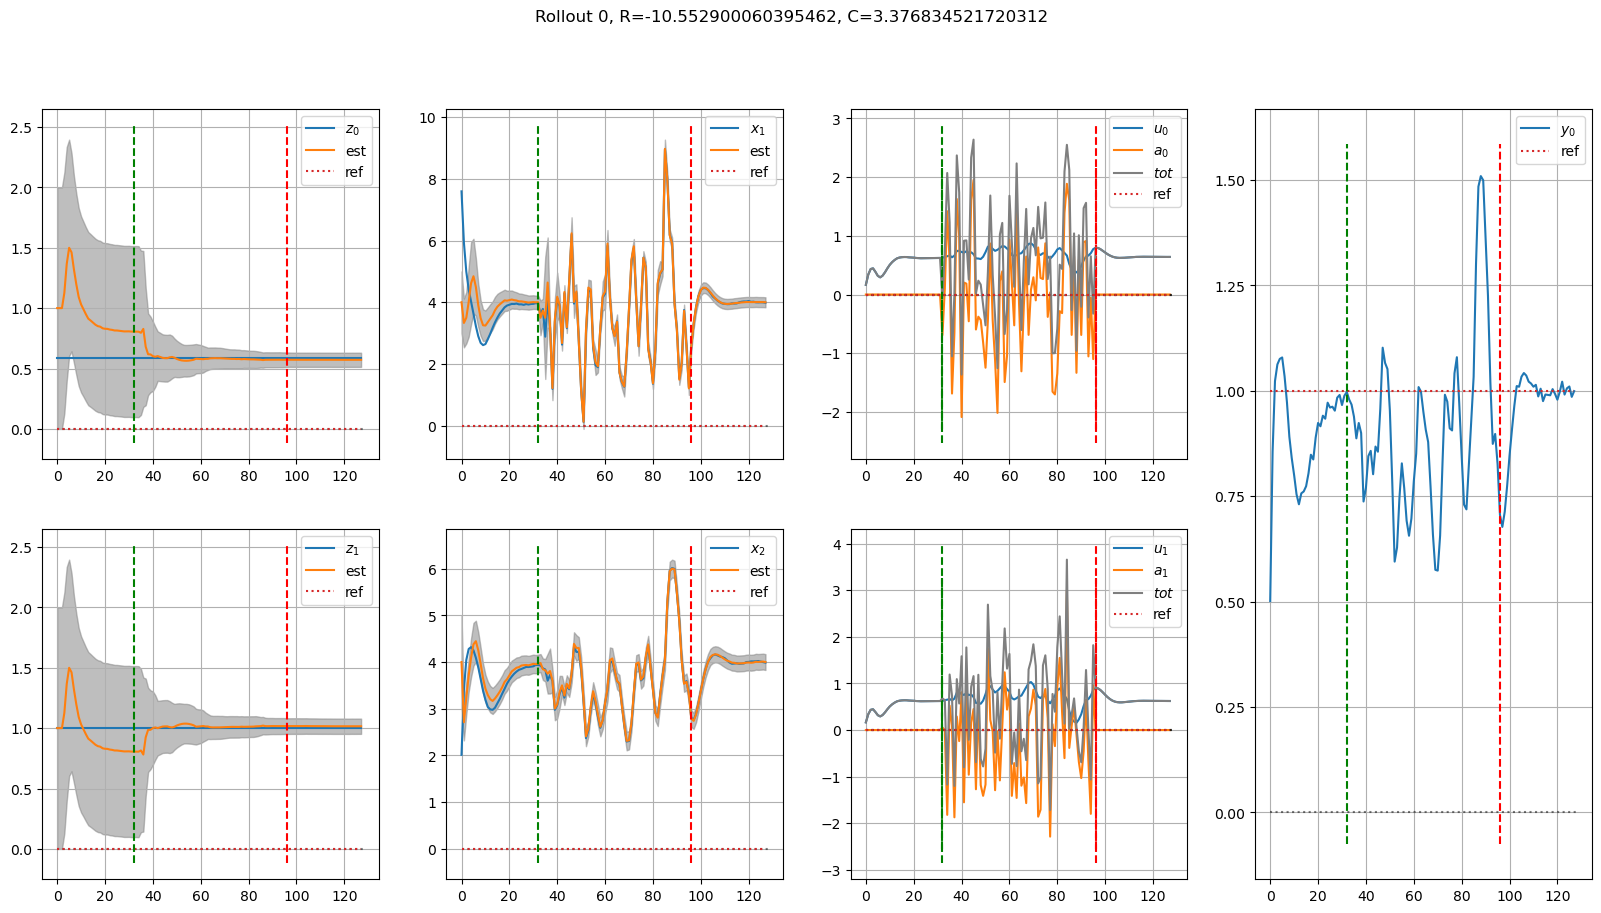

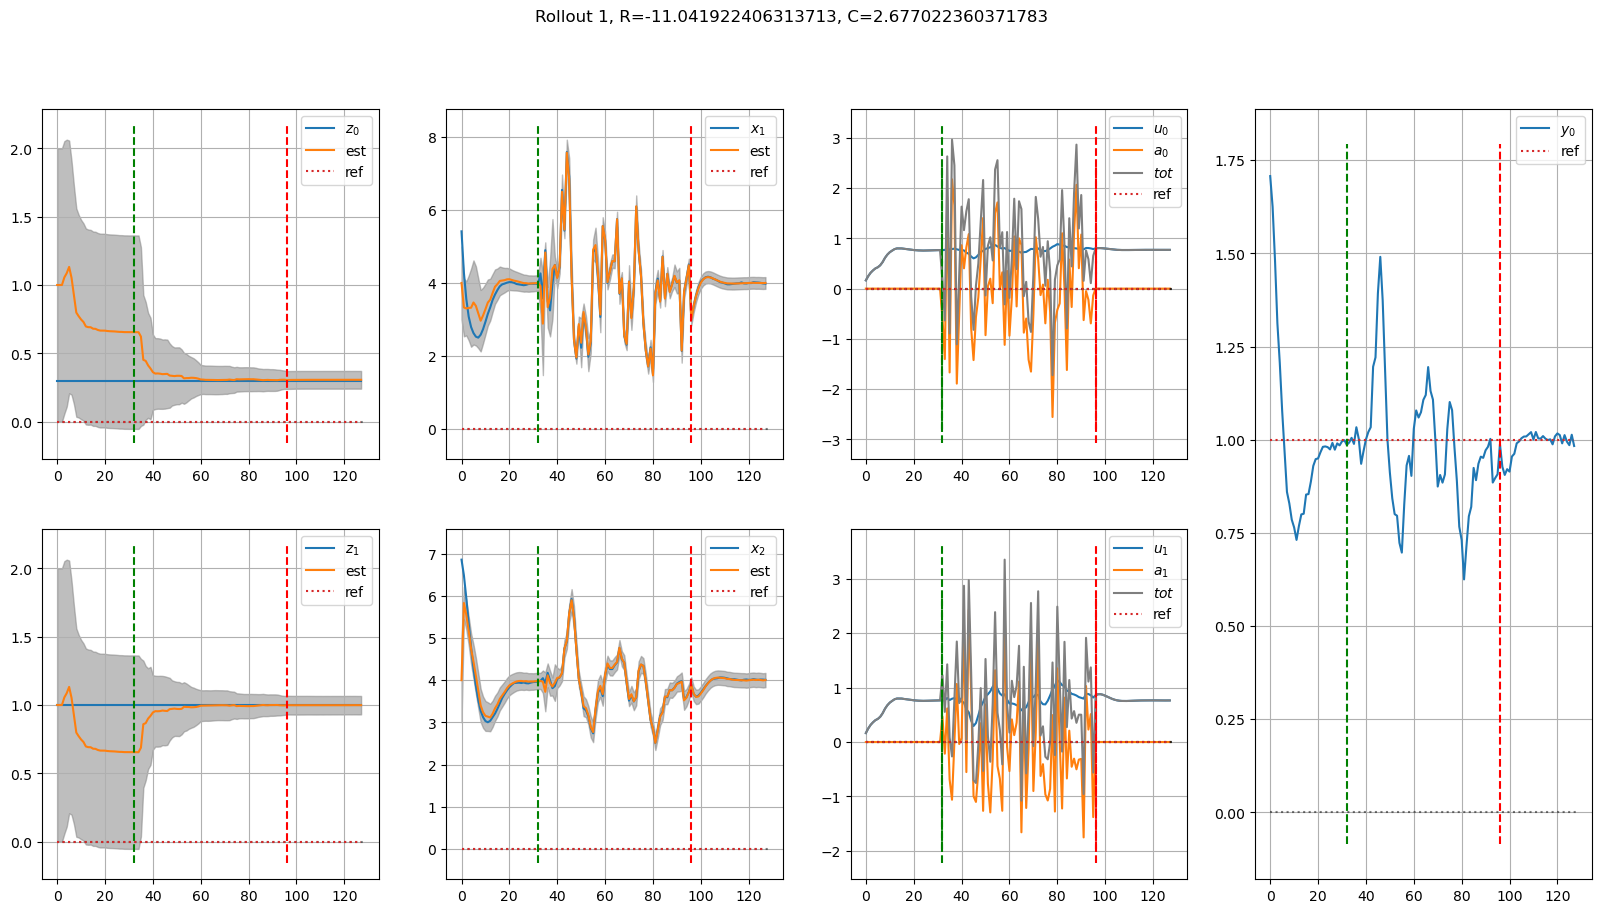

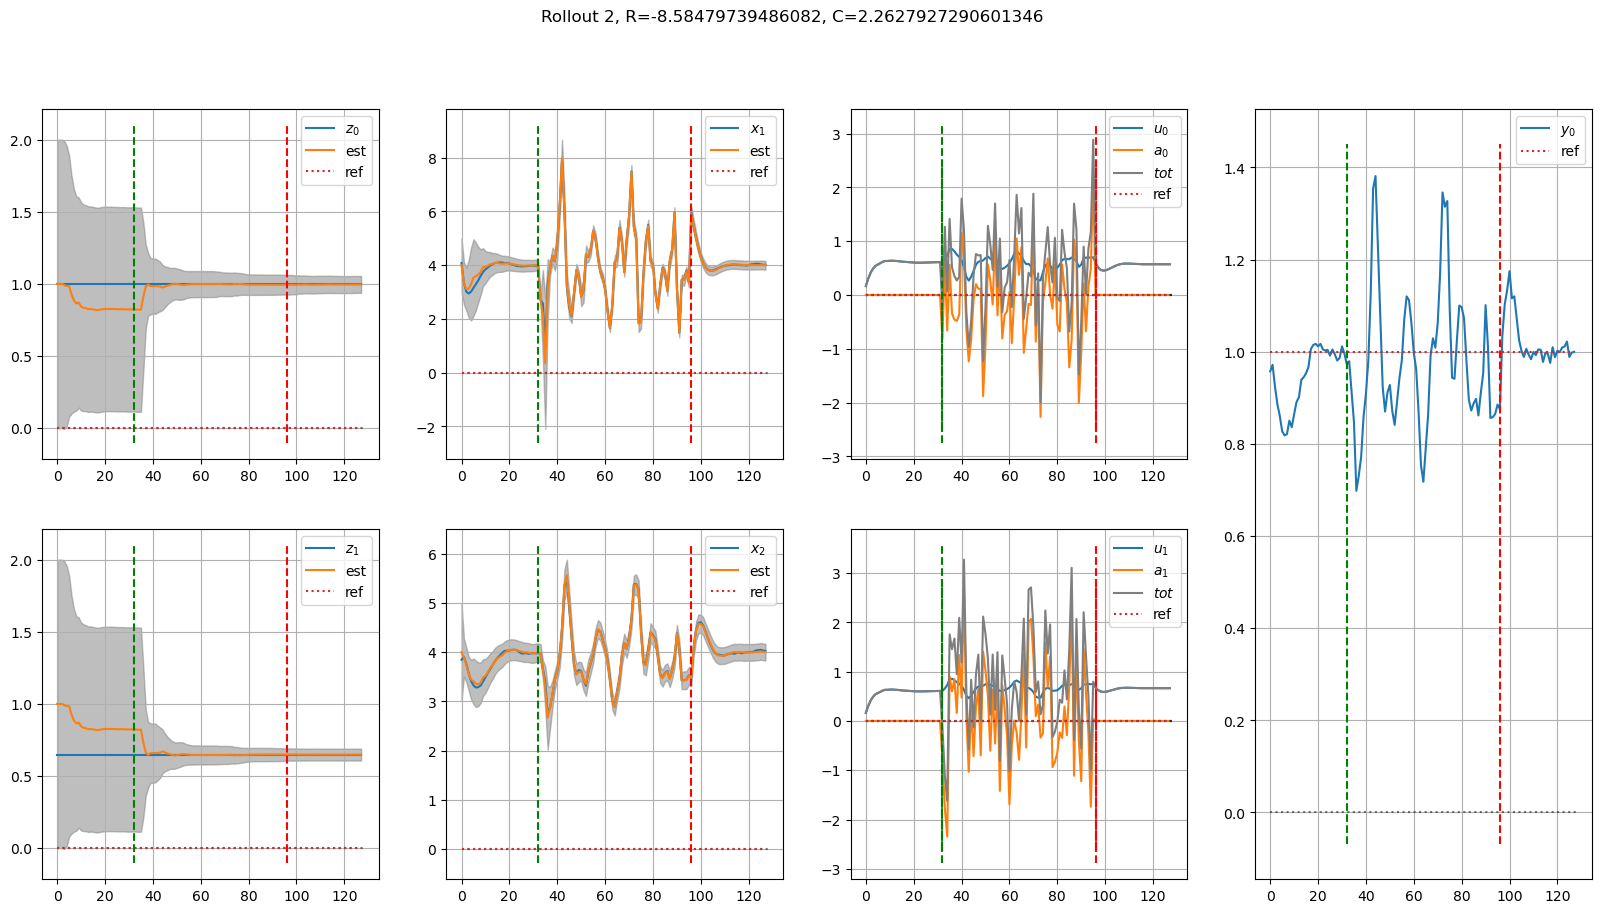

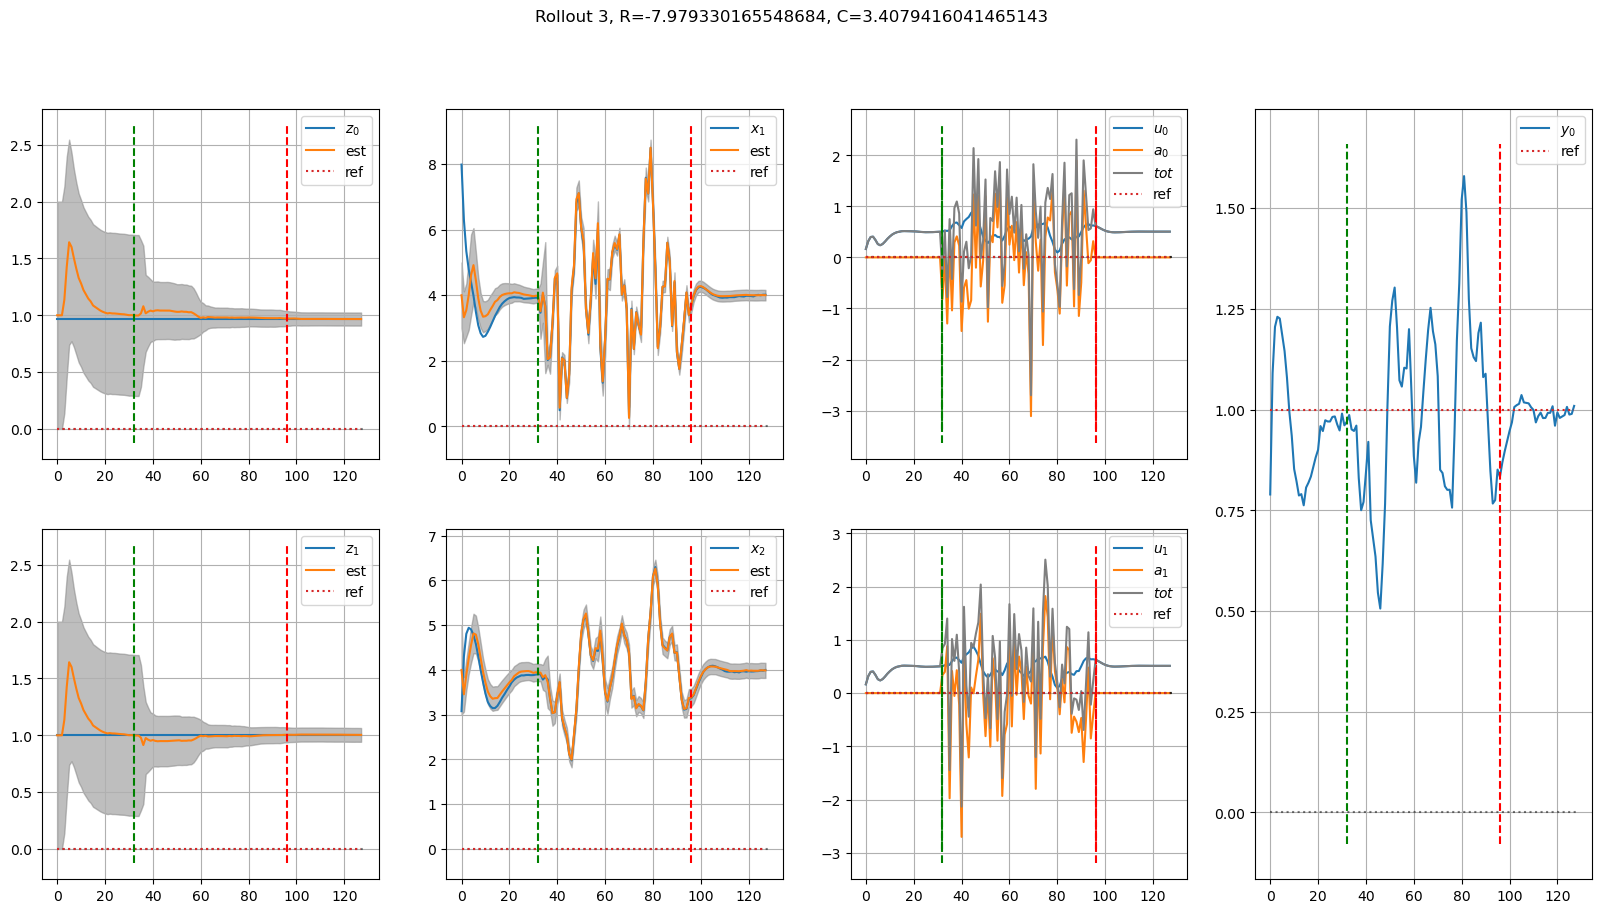

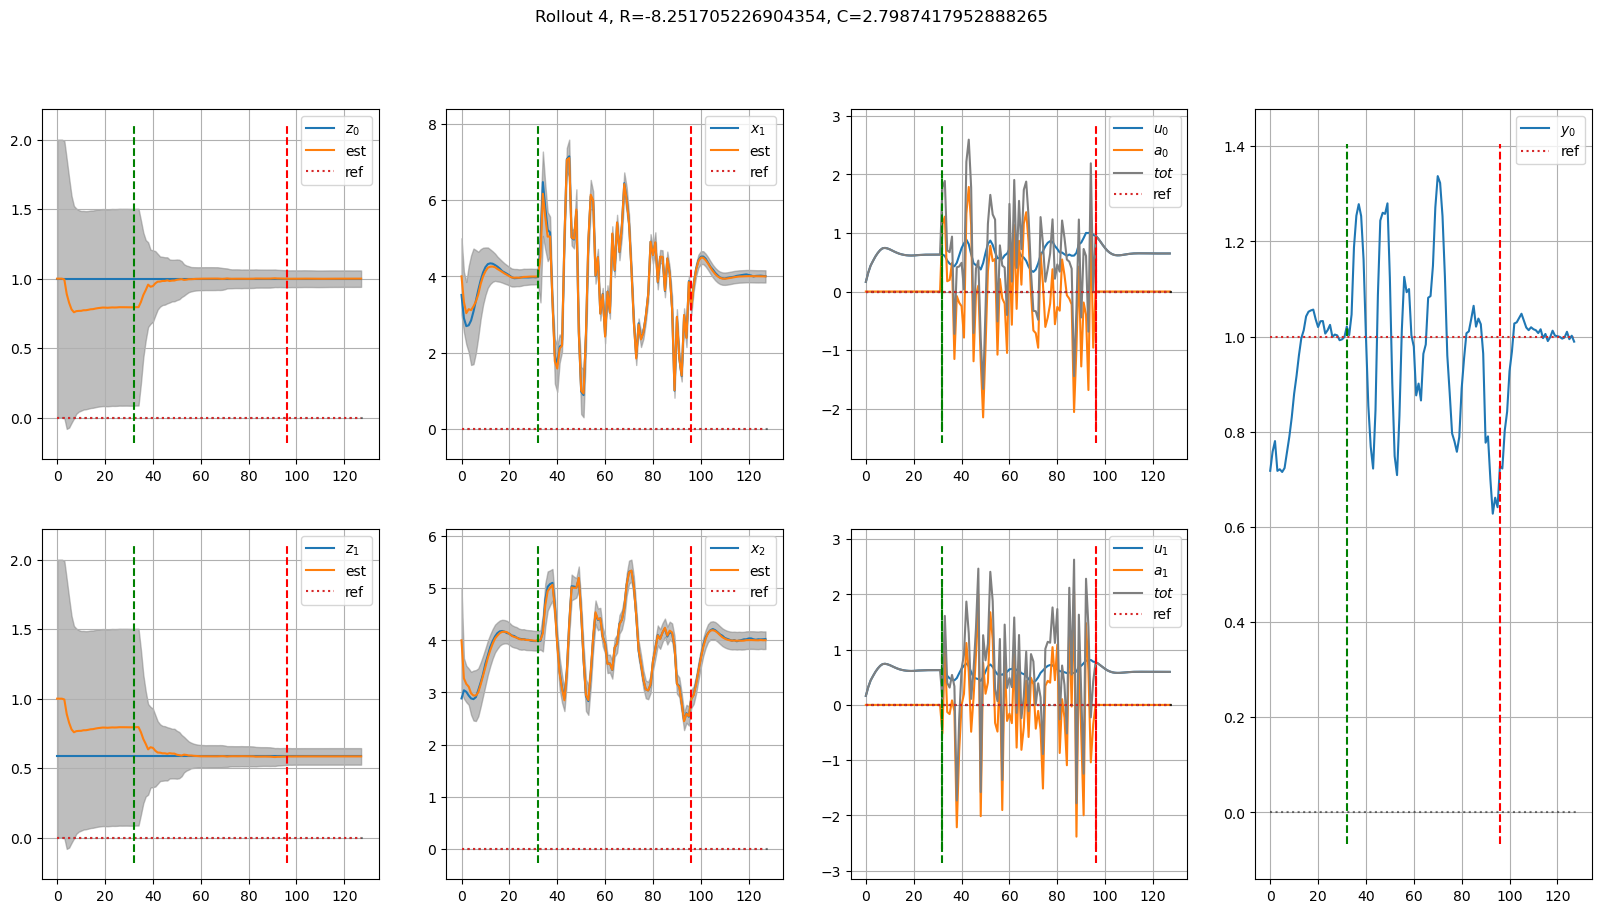

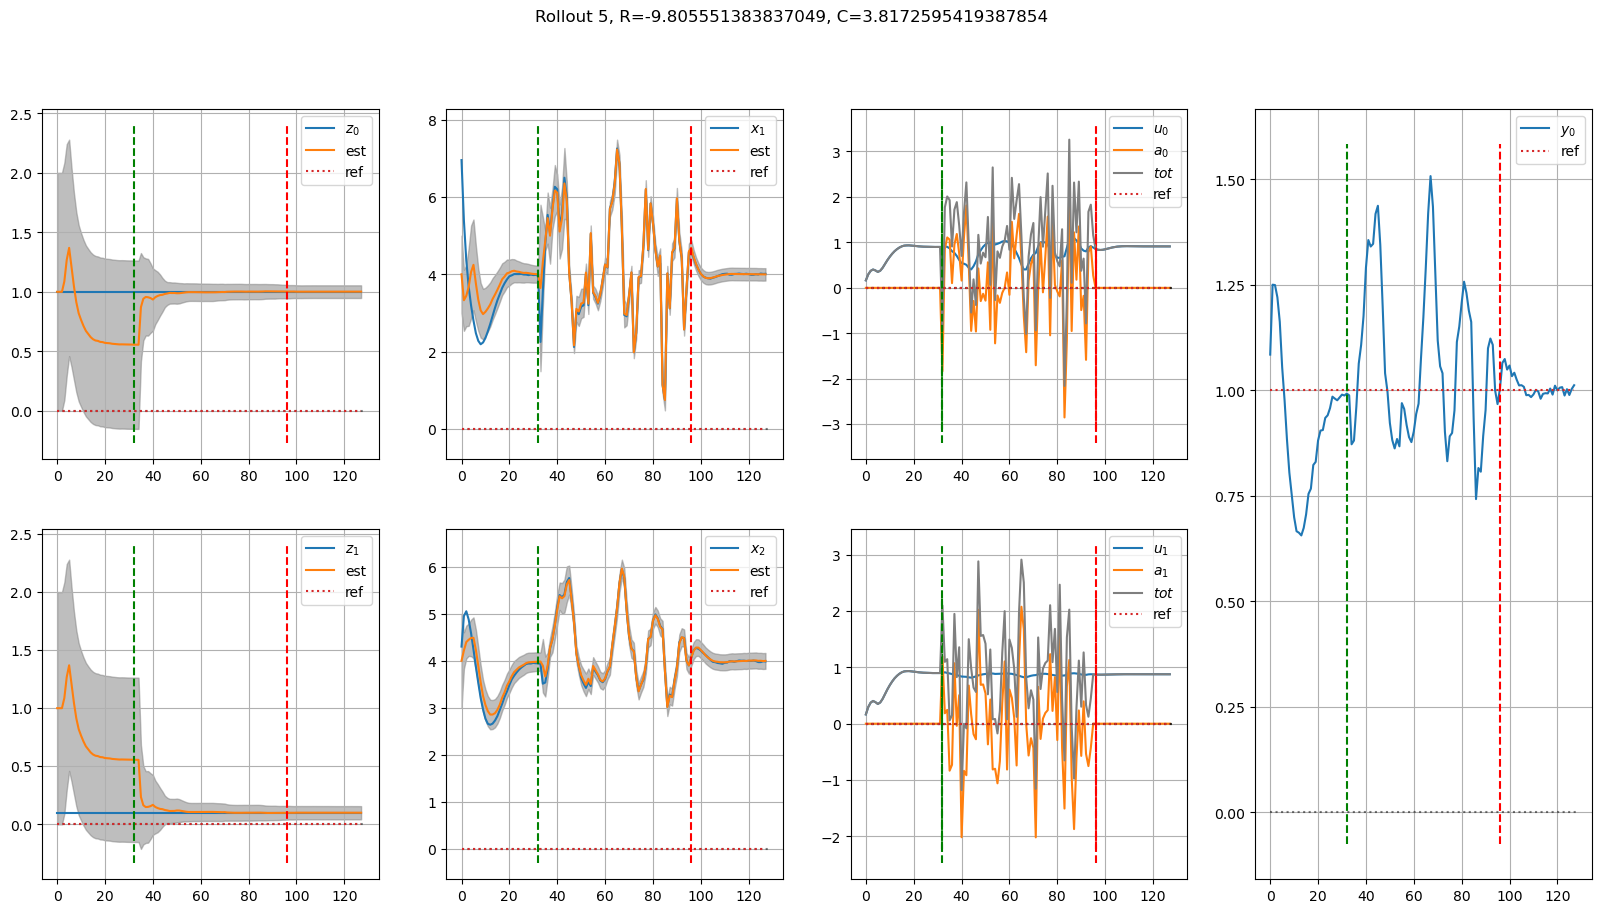

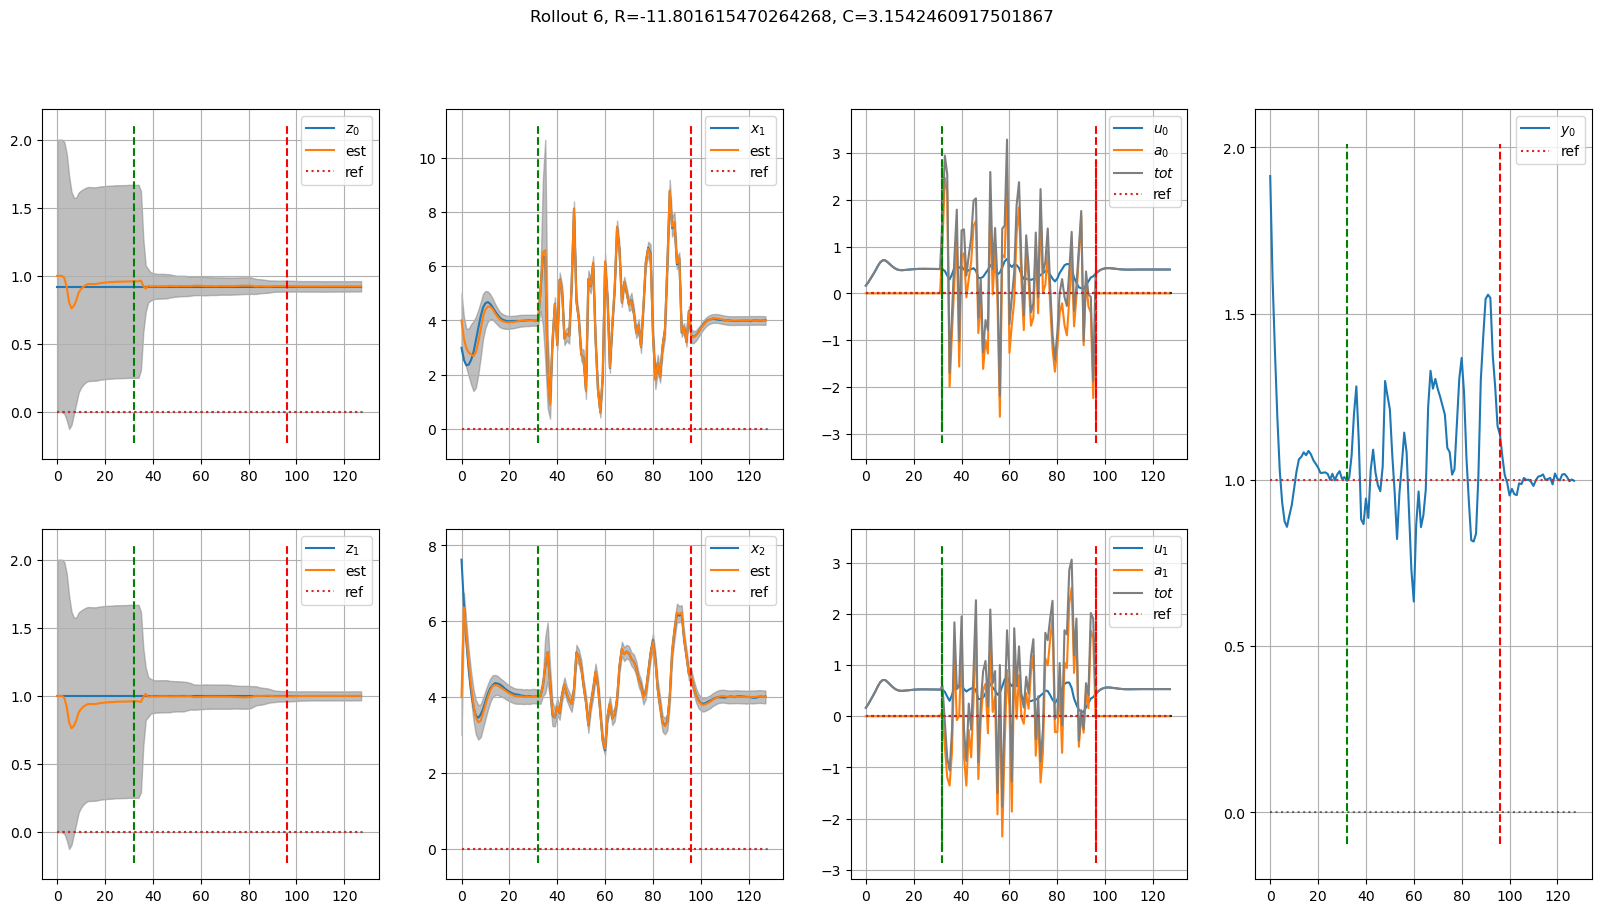

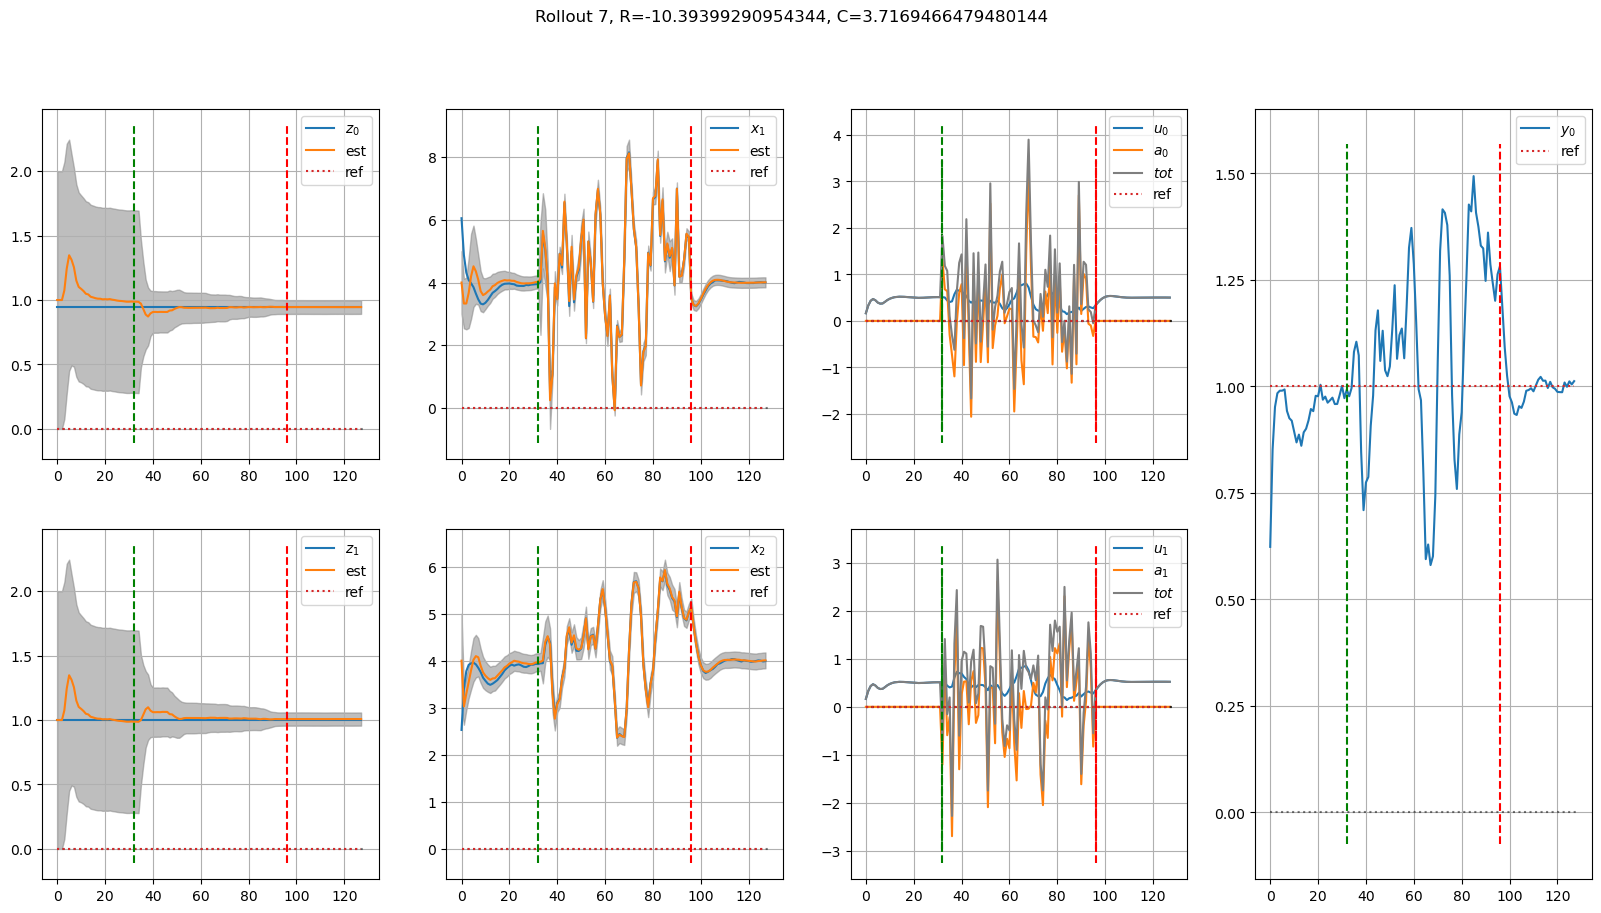

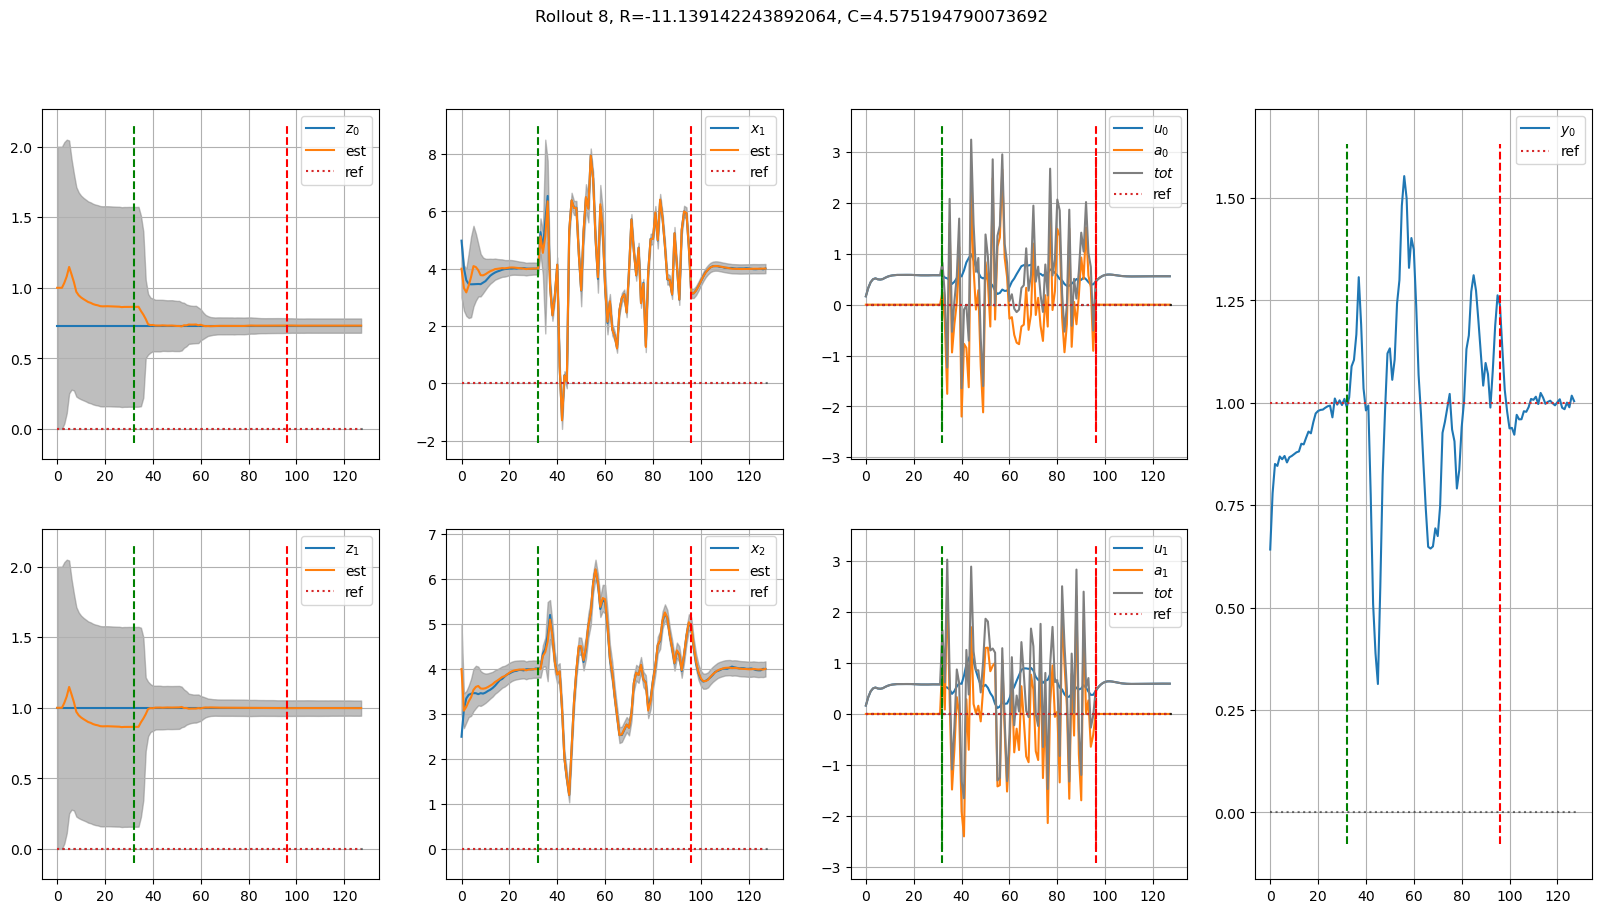

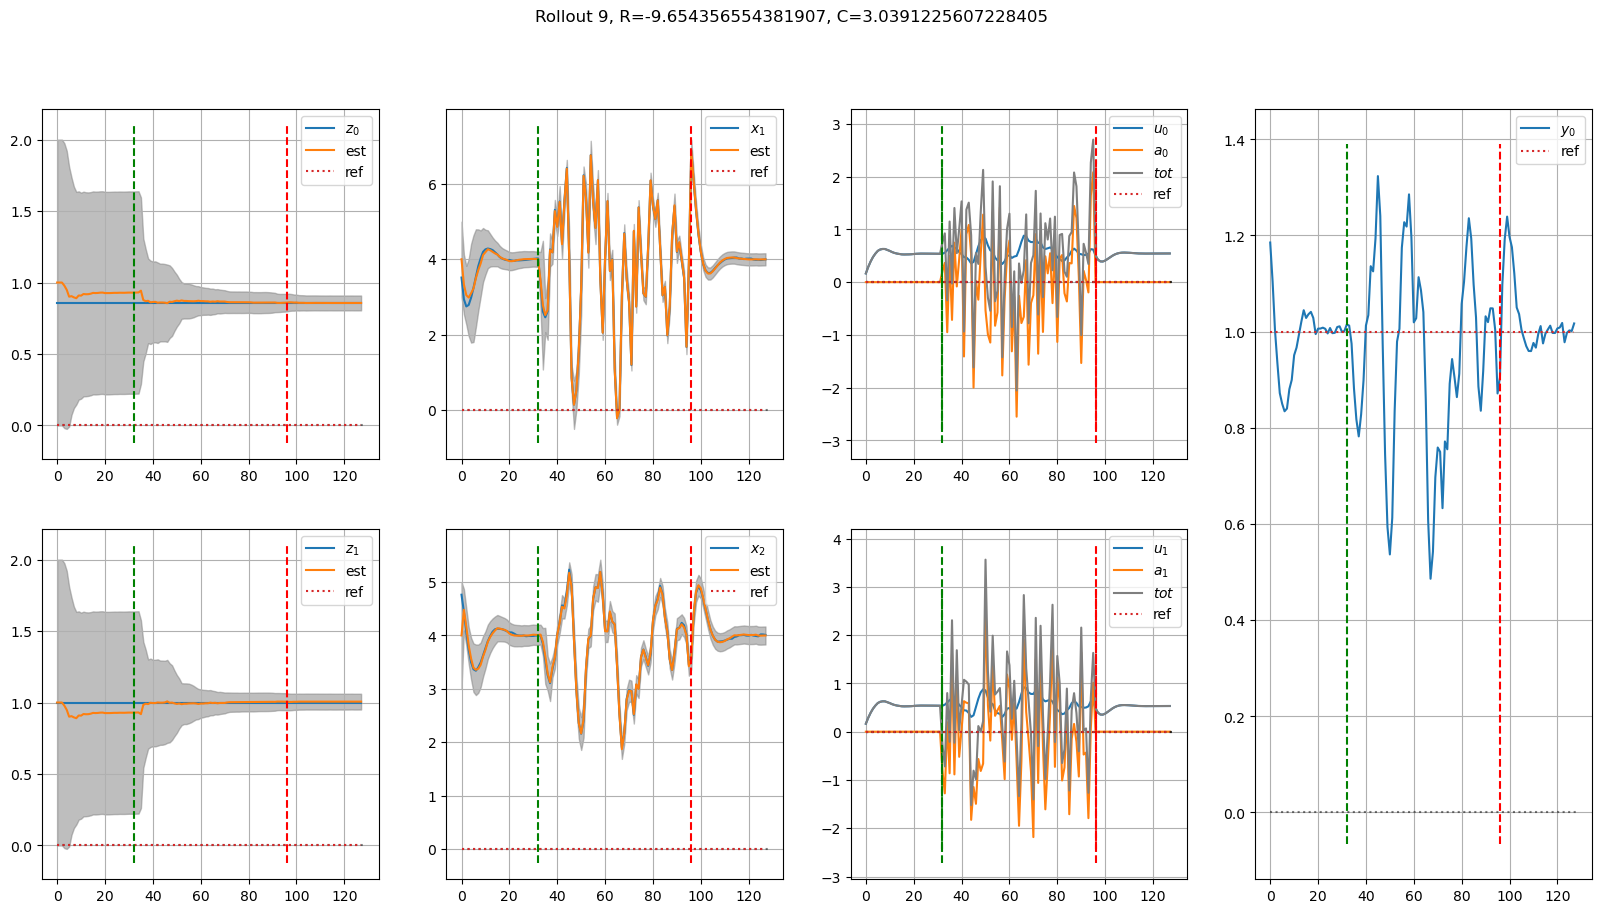

In [4]:
for i in range(10):
    rollout, out = env.rollout(trainer.policy, 128)
    R, _ = get_returns(rollout.r, trainer.discount)
    C, _ = get_returns(rollout.c, trainer.discount)
    env.render(out, title=f"Rollout {i}, R={R}, C={C}")

# Train

In [ ]:
logger = trainer.train(epochs=1000, episode_length=128)
nnx.display(trainer)

  0%|          | 0/1000 [00:00<?, ?it/s]

  4%|▍         | 45/1000 [00:13<04:08,  3.85it/s, C=2.33, V=-16.2, cost=0.0276, reward=-.259]

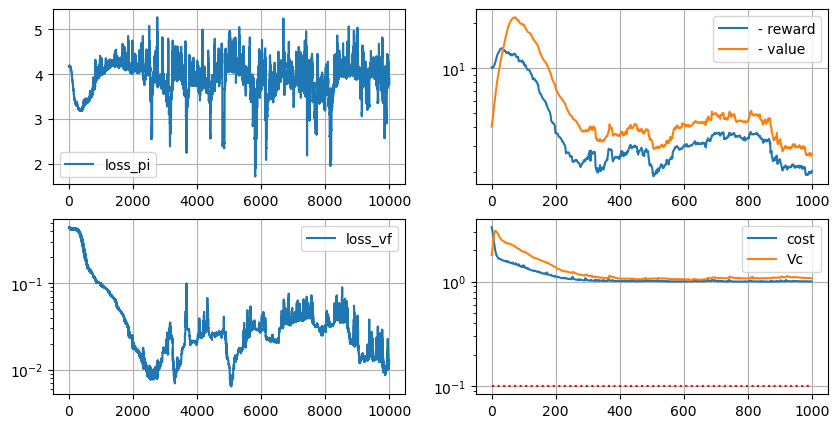

In [ ]:
import matplotlib.pyplot as plt

plt.figure(figsize=(10, 5))
plt.subplot(2, 2, 1)
plt.plot(logger["loss_pi"], label="loss_pi")
plt.legend()
plt.grid()
plt.subplot(2, 2, 3)
plt.semilogy(logger["loss_vf"], label="loss_vf")
plt.legend()
plt.grid()
batch_returns = lambda x: jax.vmap(
    jax.vmap(lambda x: get_returns(x, trainer.discount)[0])
)(x).mean(axis=-1)
plt.subplot(2, 2, 2)
plt.semilogy(-batch_returns(logger["reward"]), label="- reward")
plt.semilogy(-logger["V"][:, :, 0].mean(axis=-1), label="- value")
plt.legend()
plt.grid()
plt.subplot(2, 2, 4)
plt.semilogy(batch_returns(logger["cost"]), label="cost")
plt.semilogy(logger["C"][:, :, 0].mean(axis=-1), label="Vc")
plt.semilogy([0, len(logger["C"])], (trainer.max_cost,) * 2, "r:")
plt.legend()
plt.grid()
plt.show()

# Trained Policy

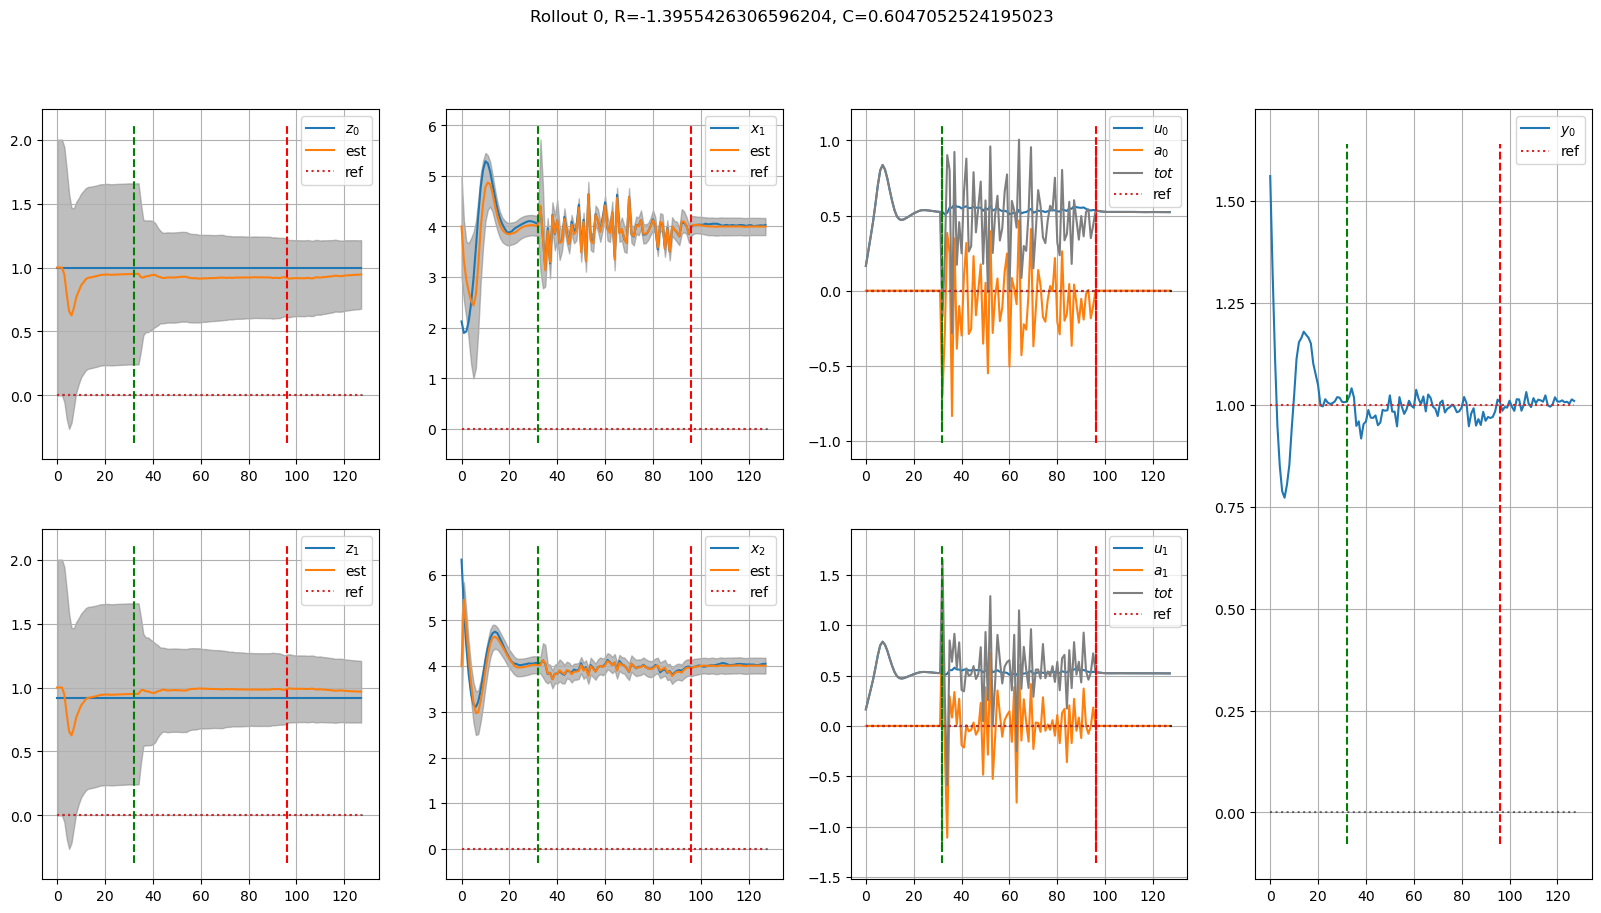

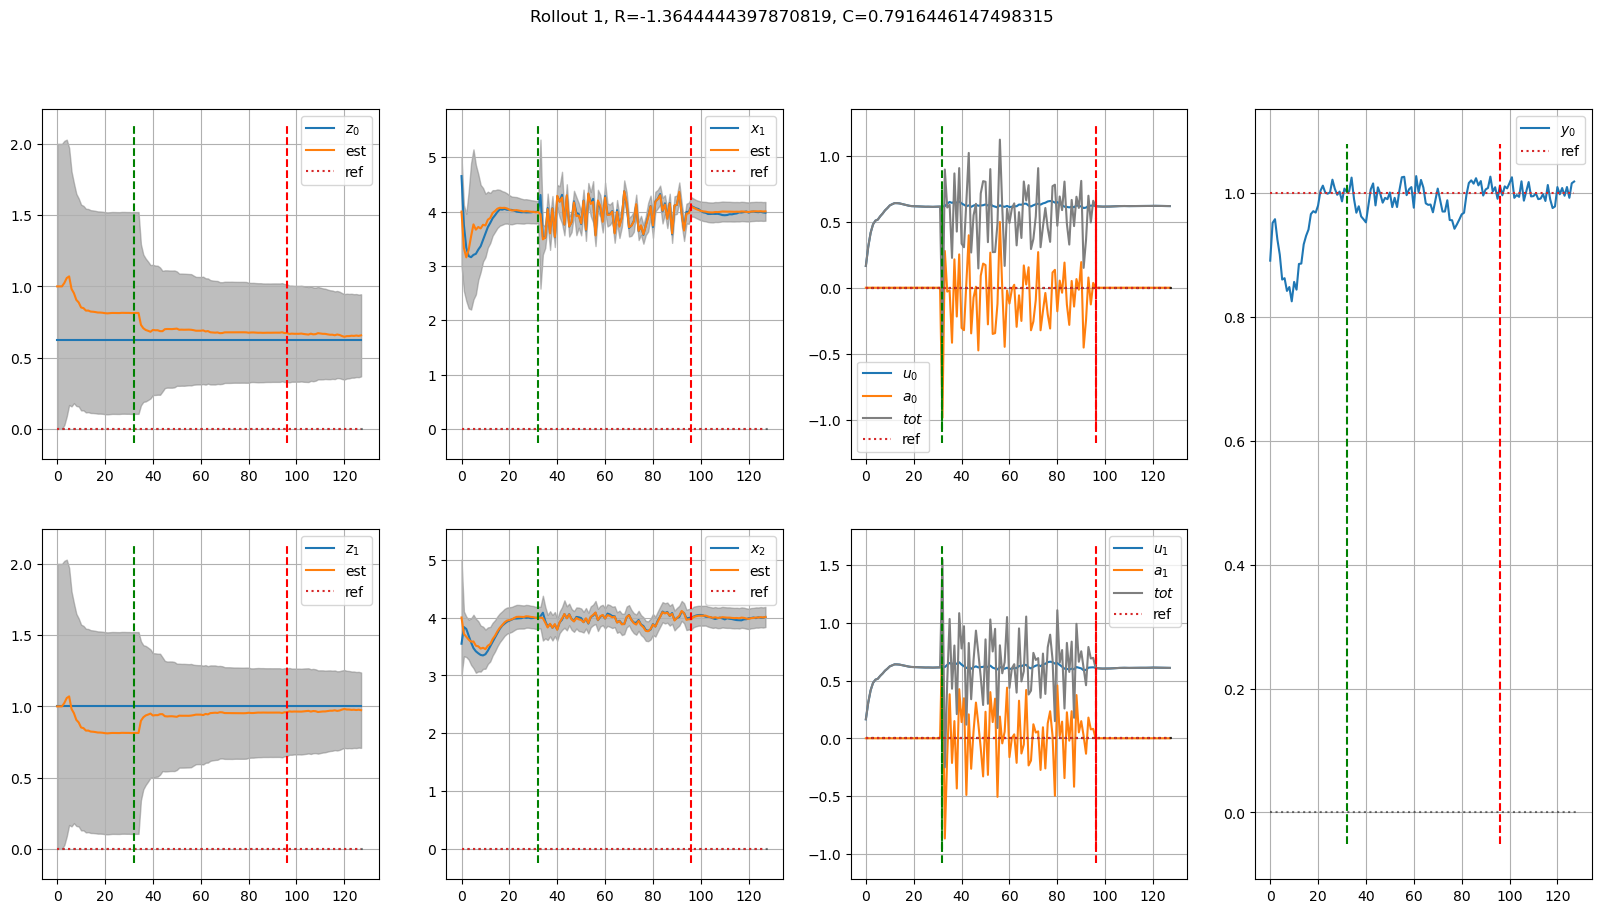

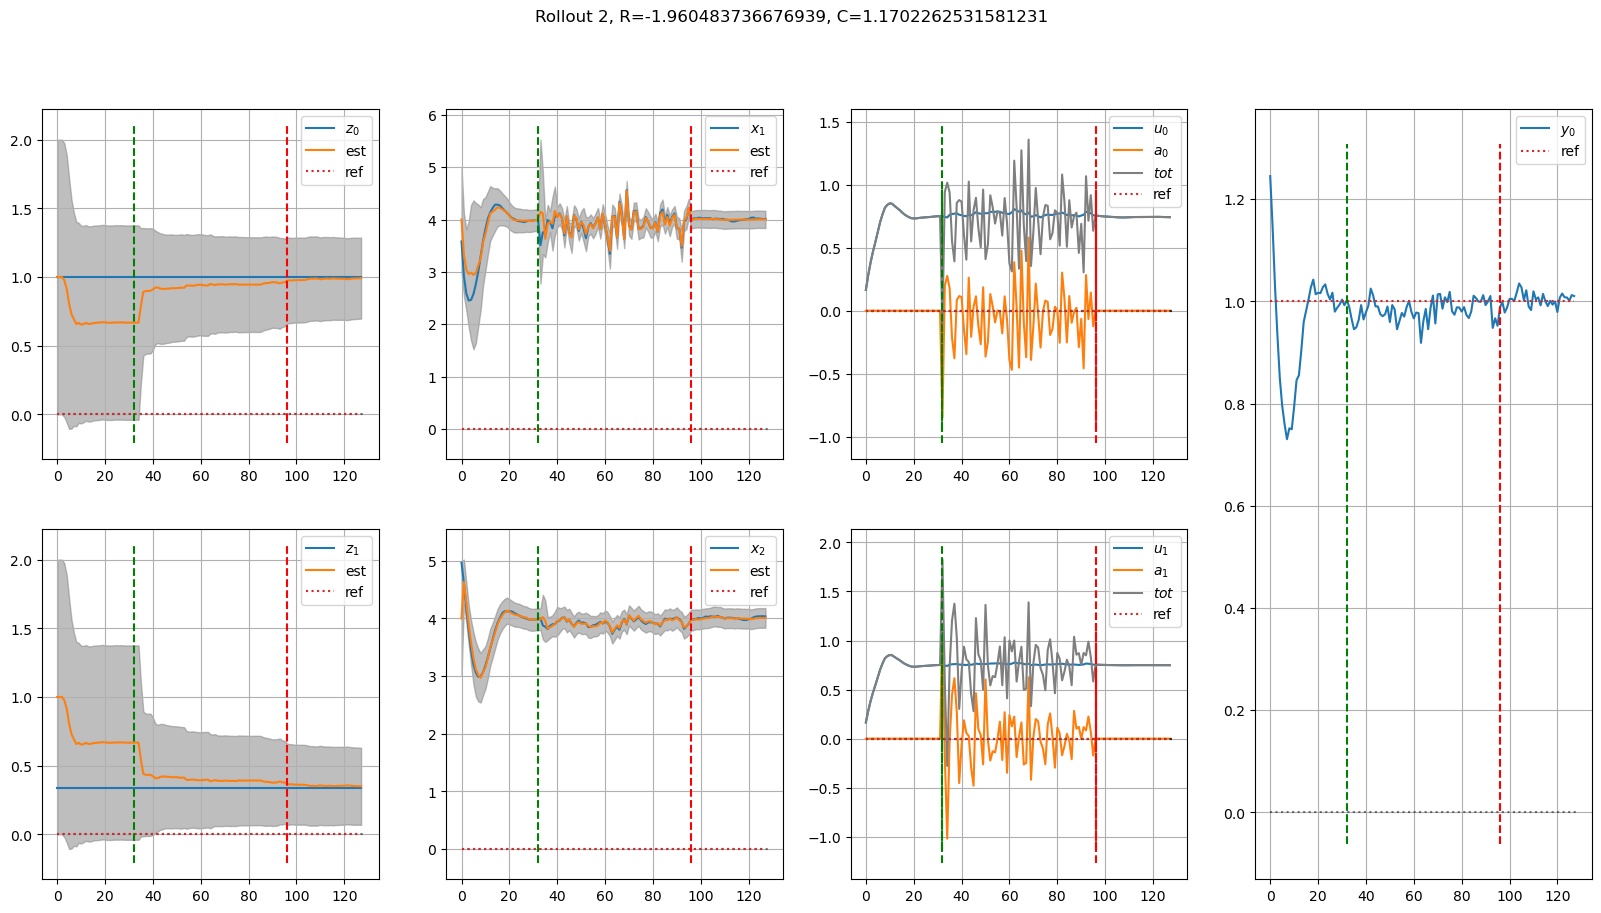

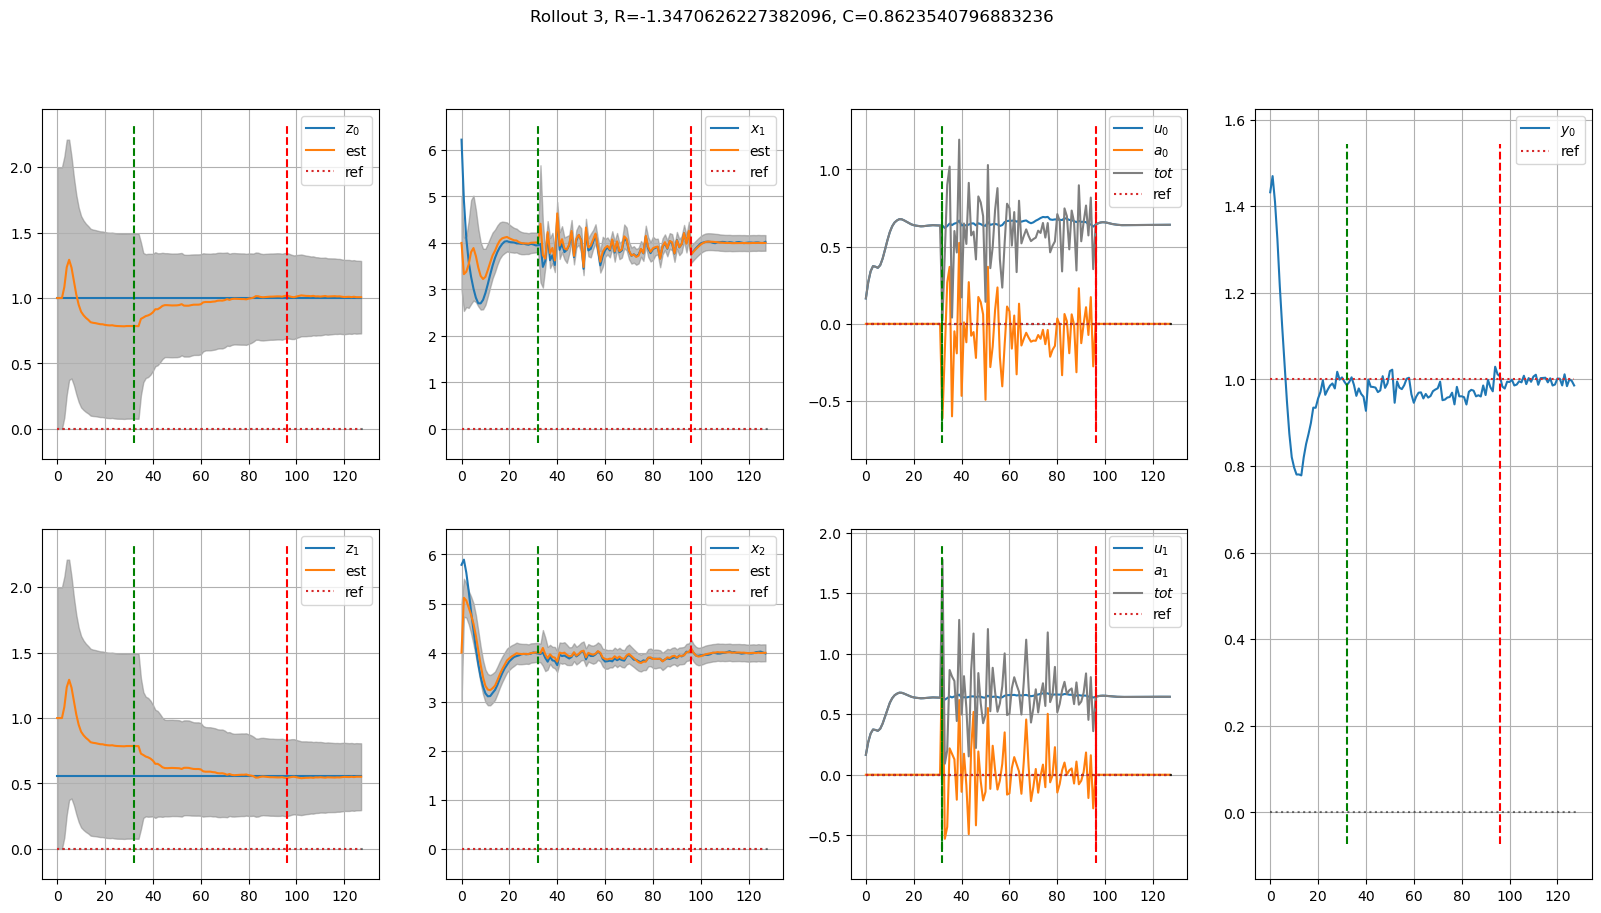

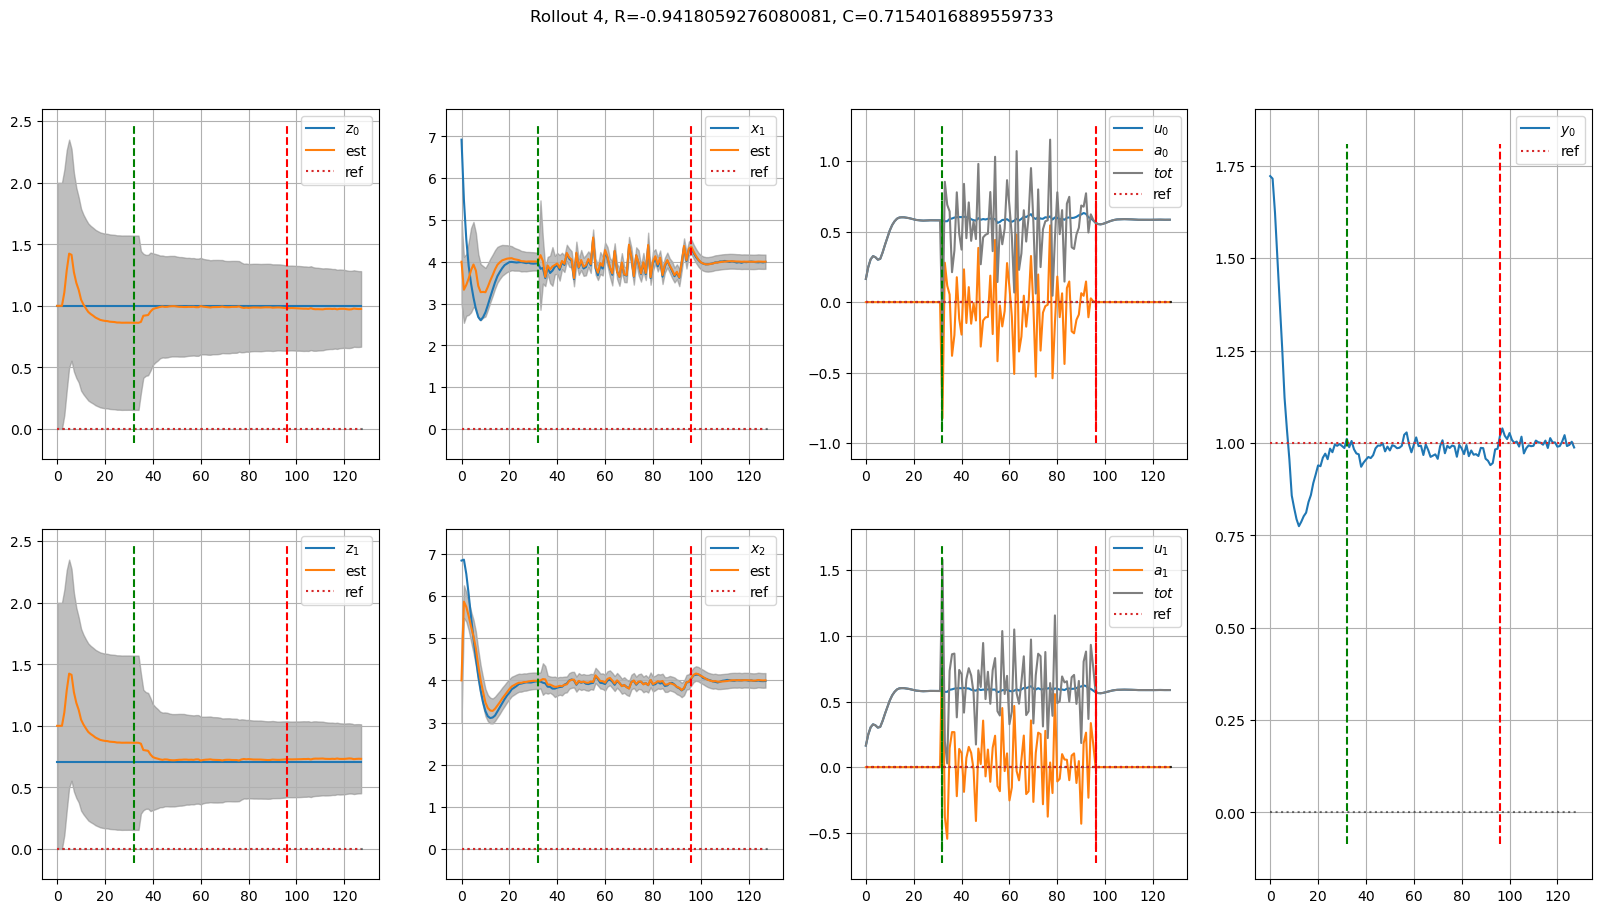

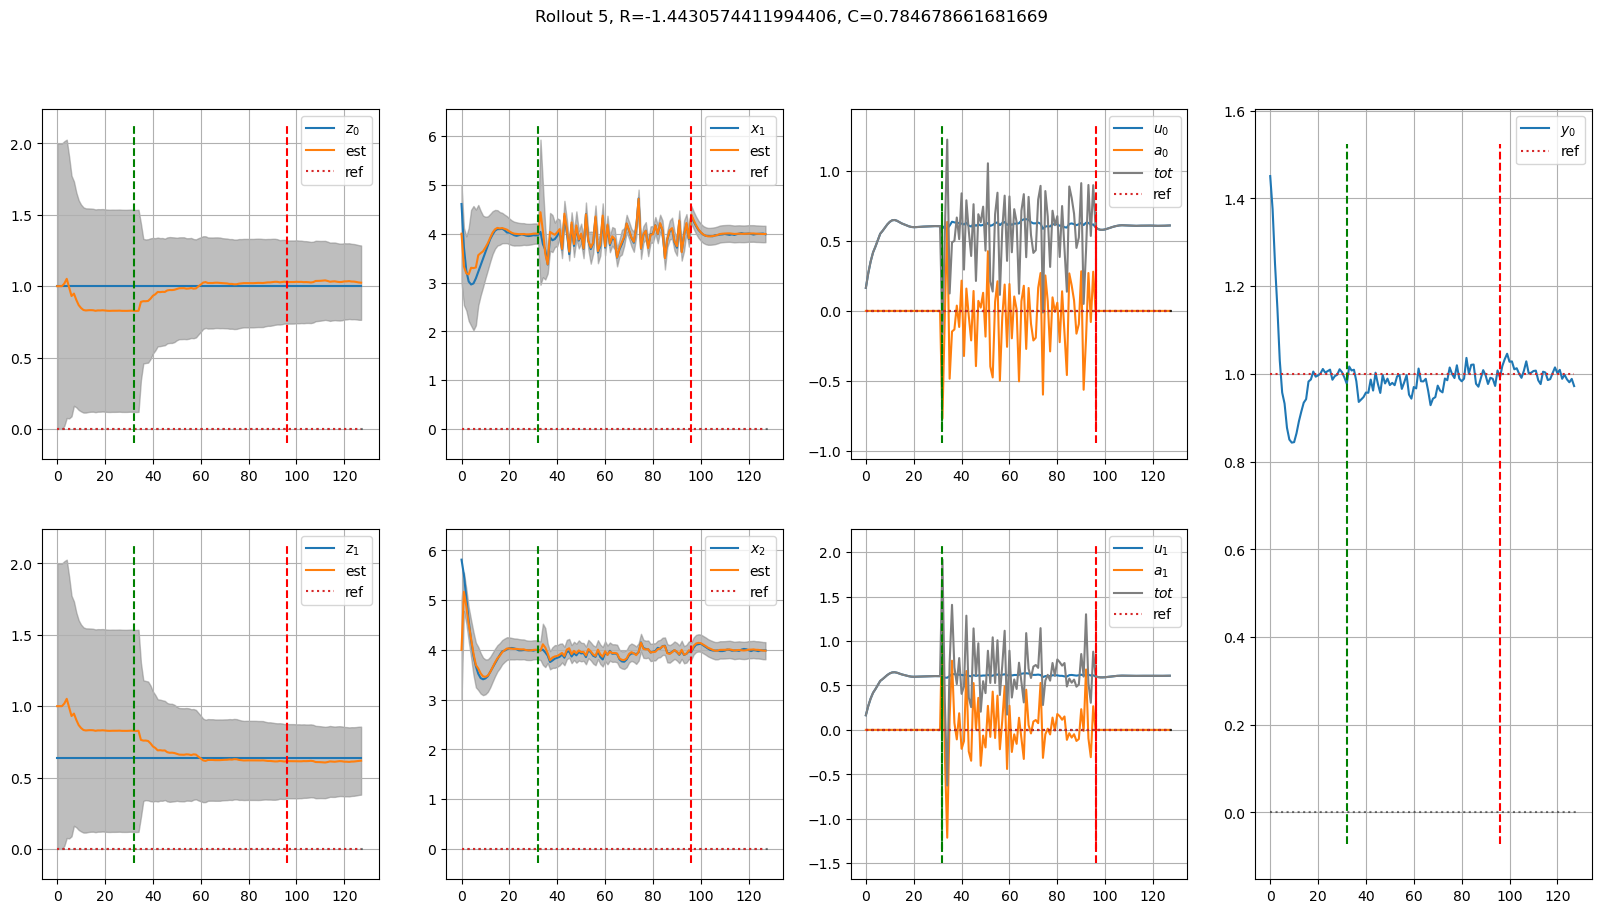

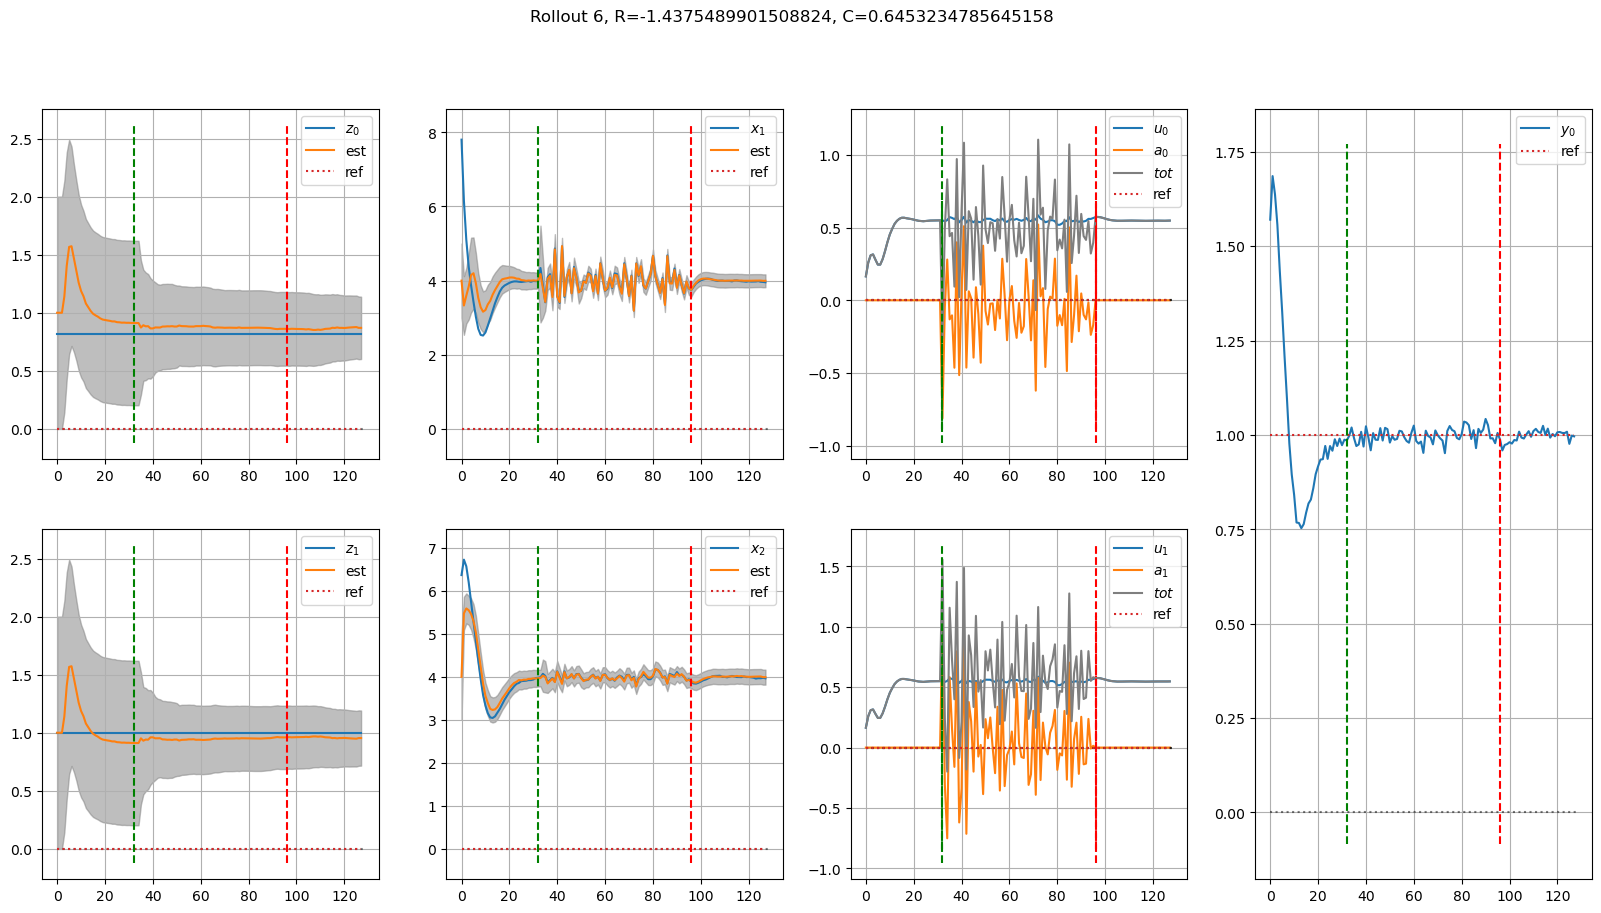

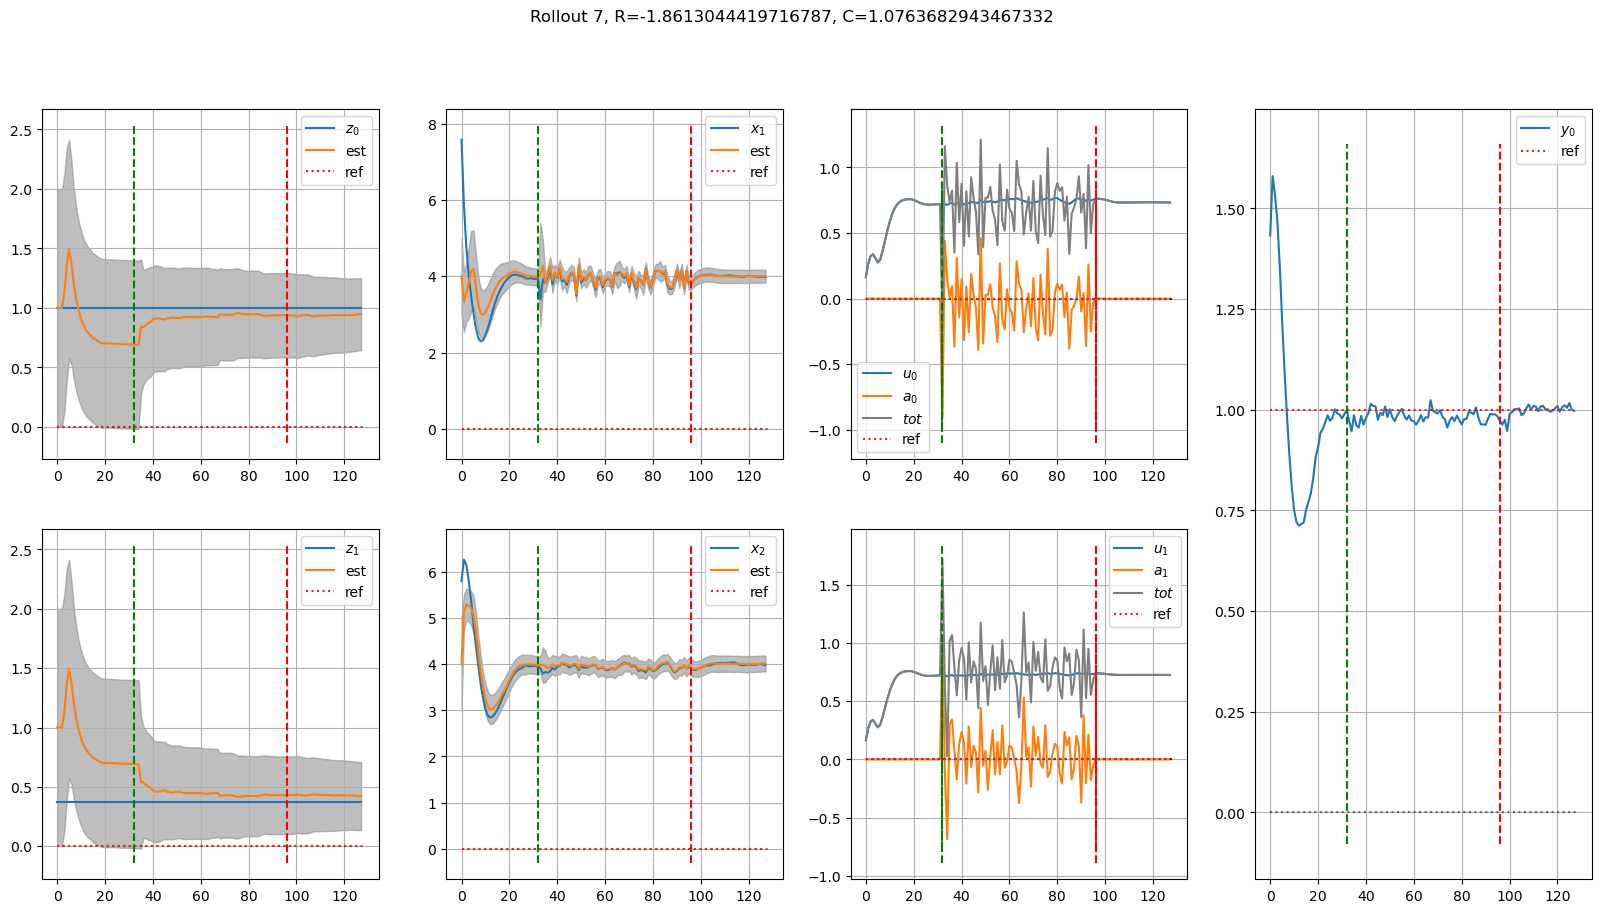

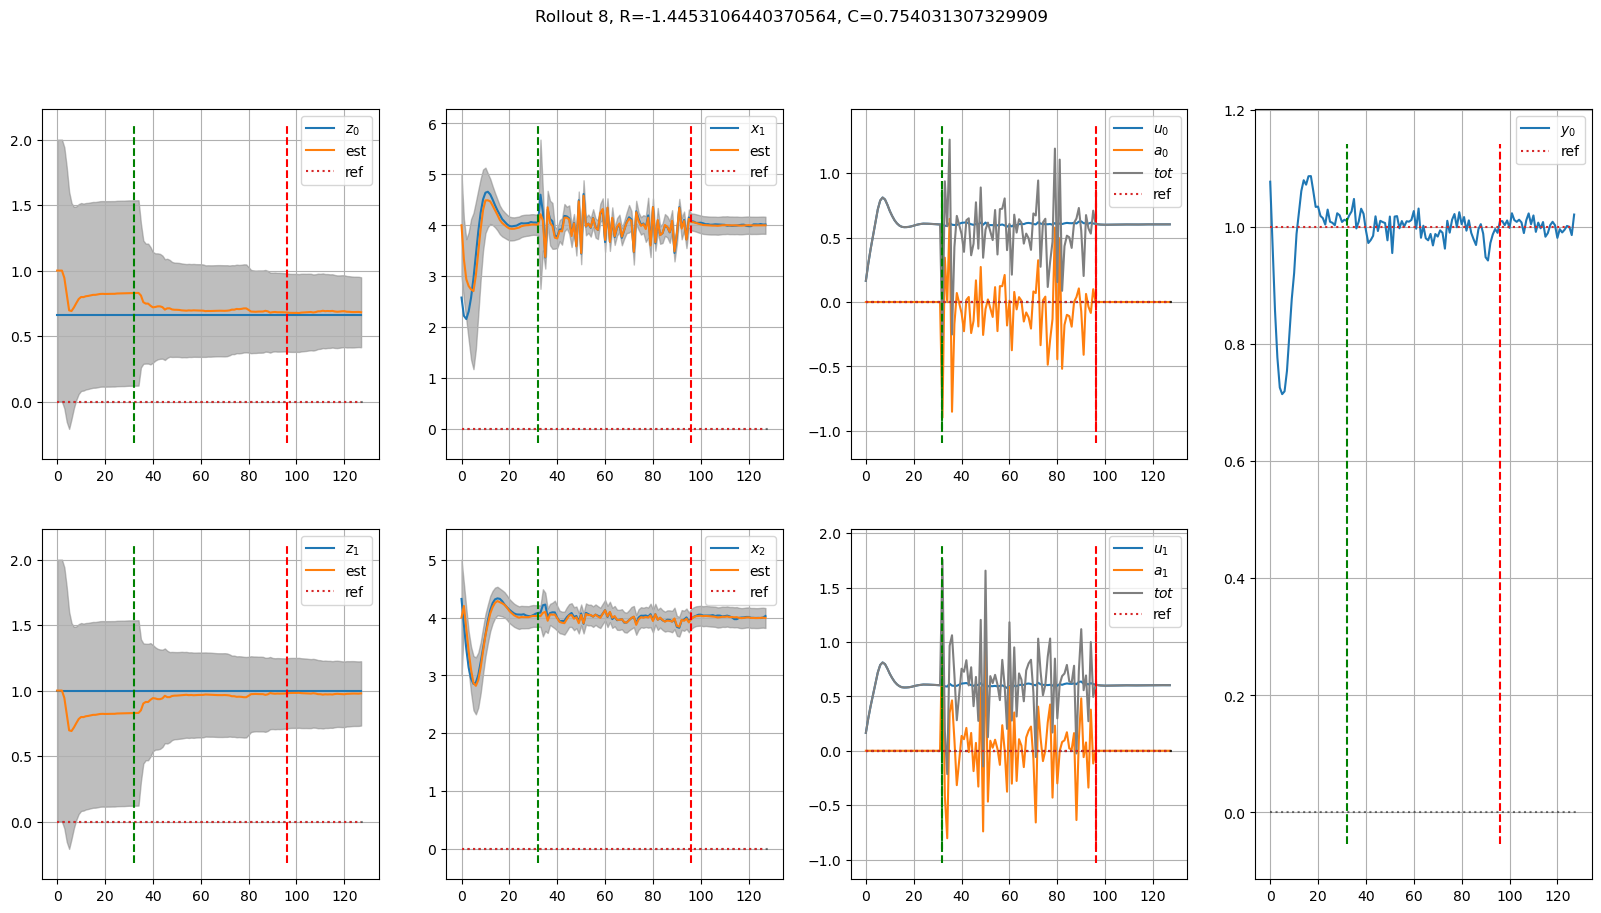

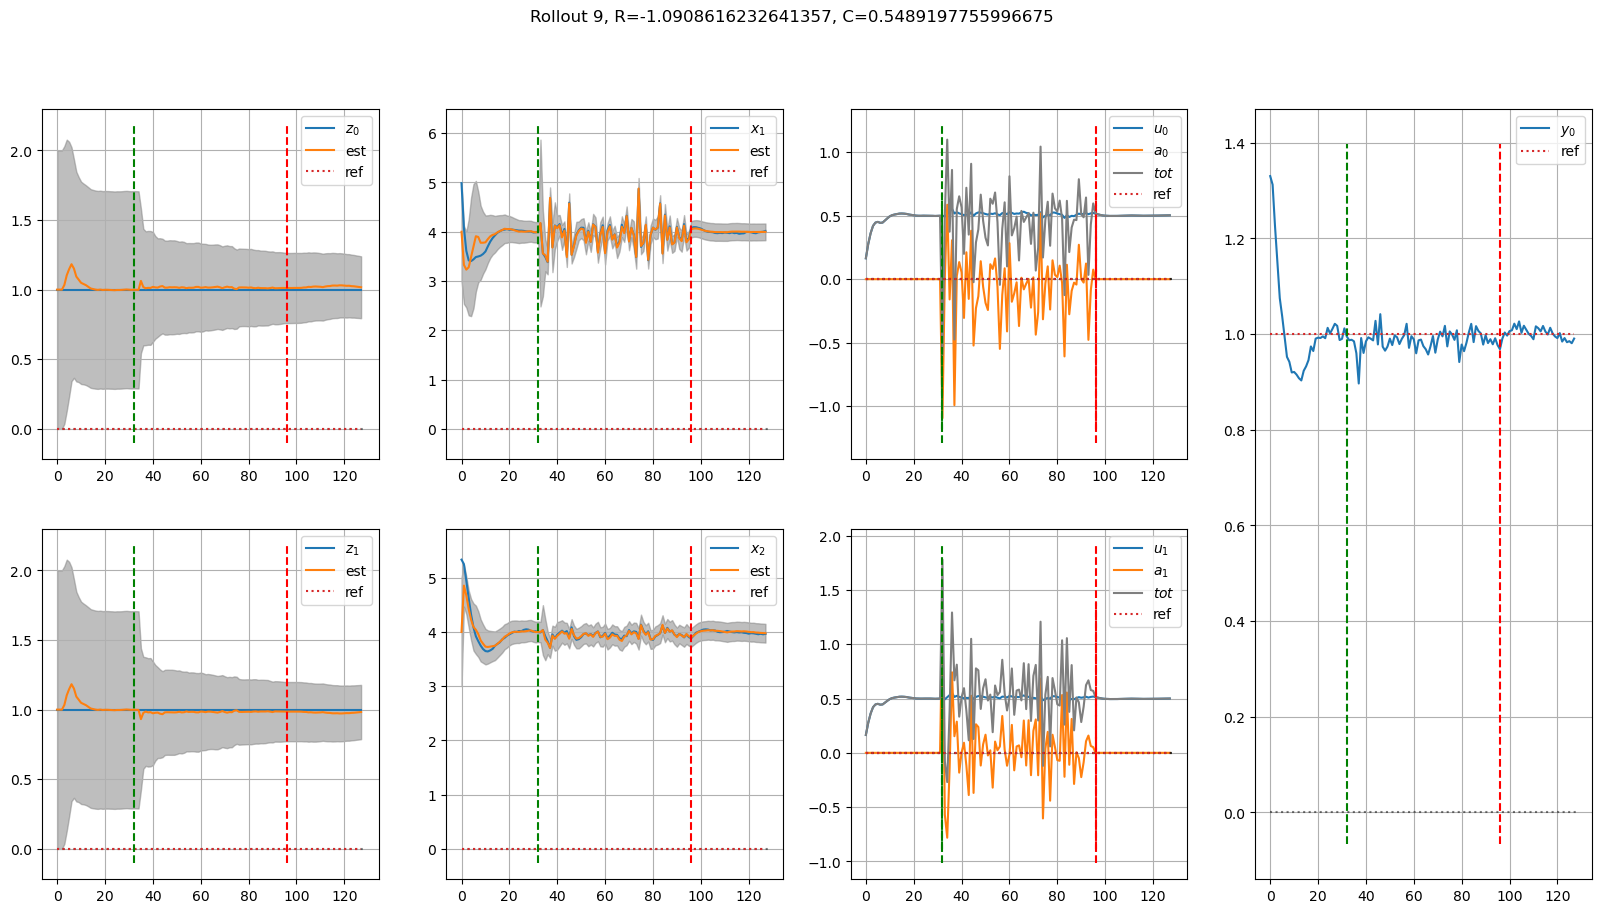

In [ ]:
for i in range(10):
    rollout, out = env.rollout(trainer.policy, 128)
    R, _ = get_returns(rollout.r, trainer.discount)
    C, _ = get_returns(rollout.c, trainer.discount)
    env.render(out, title=f"Rollout {i}, R={R}, C={C}")

# Trained Deterministic

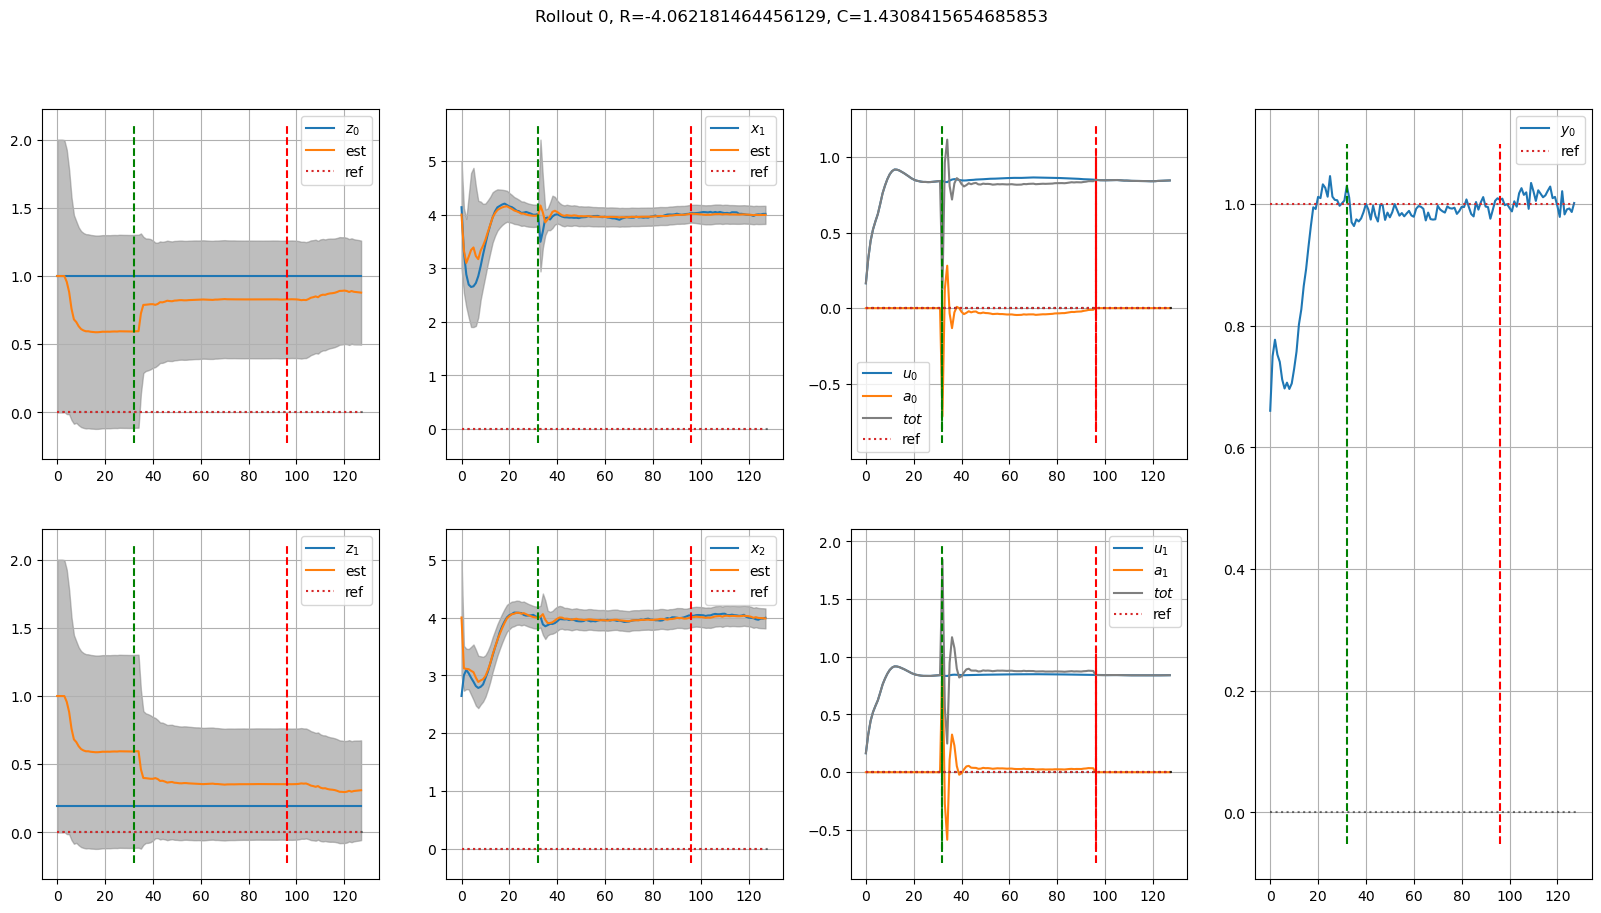

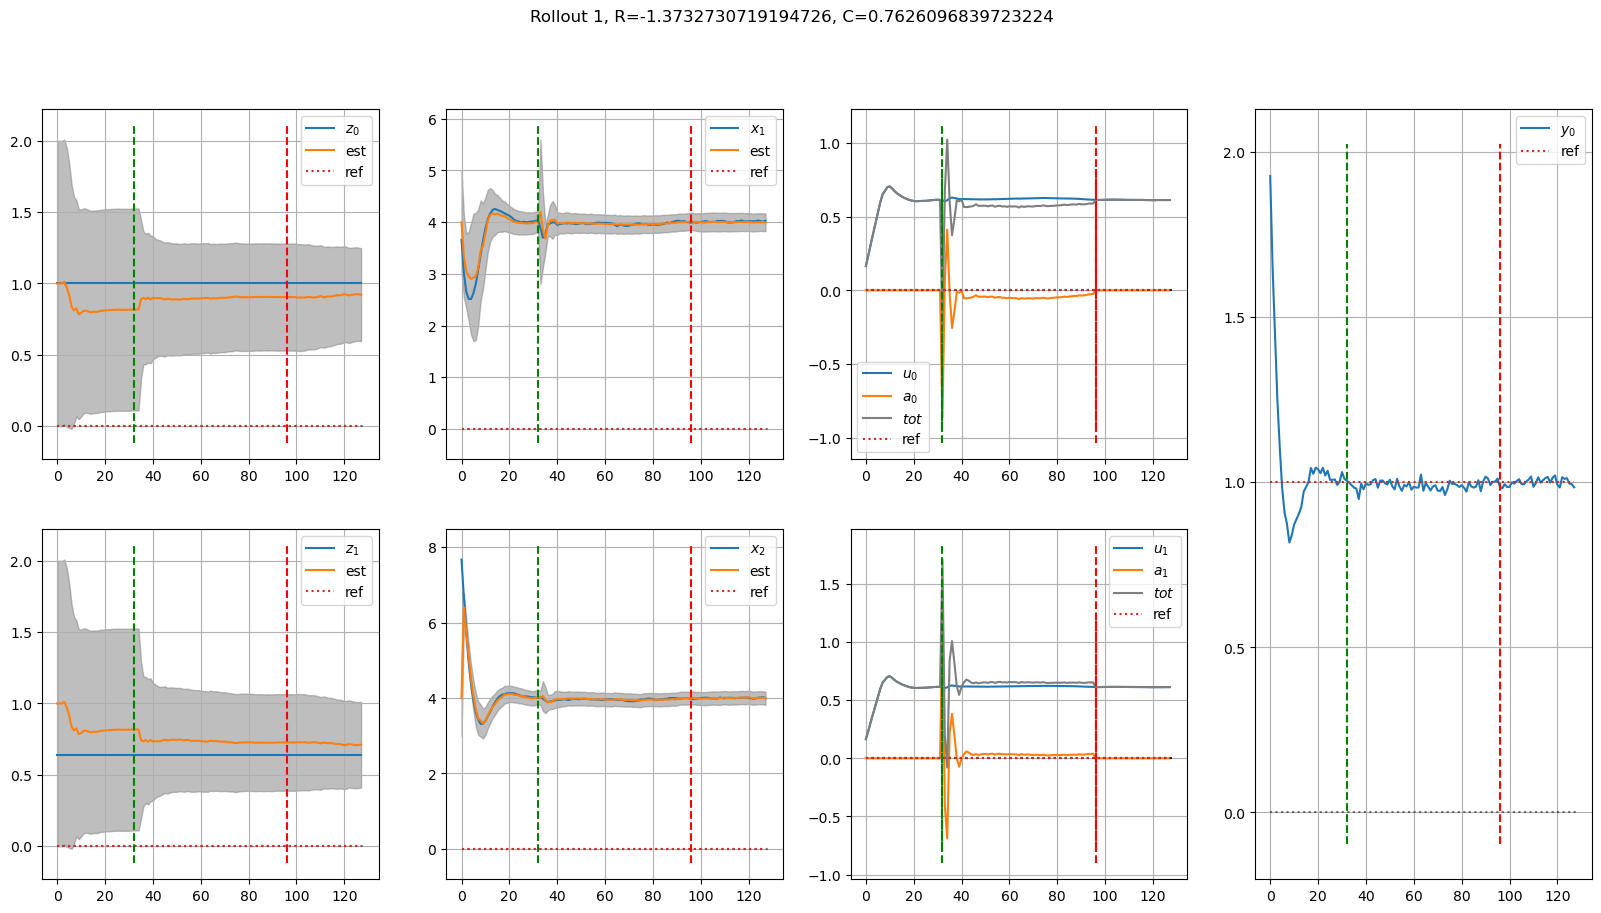

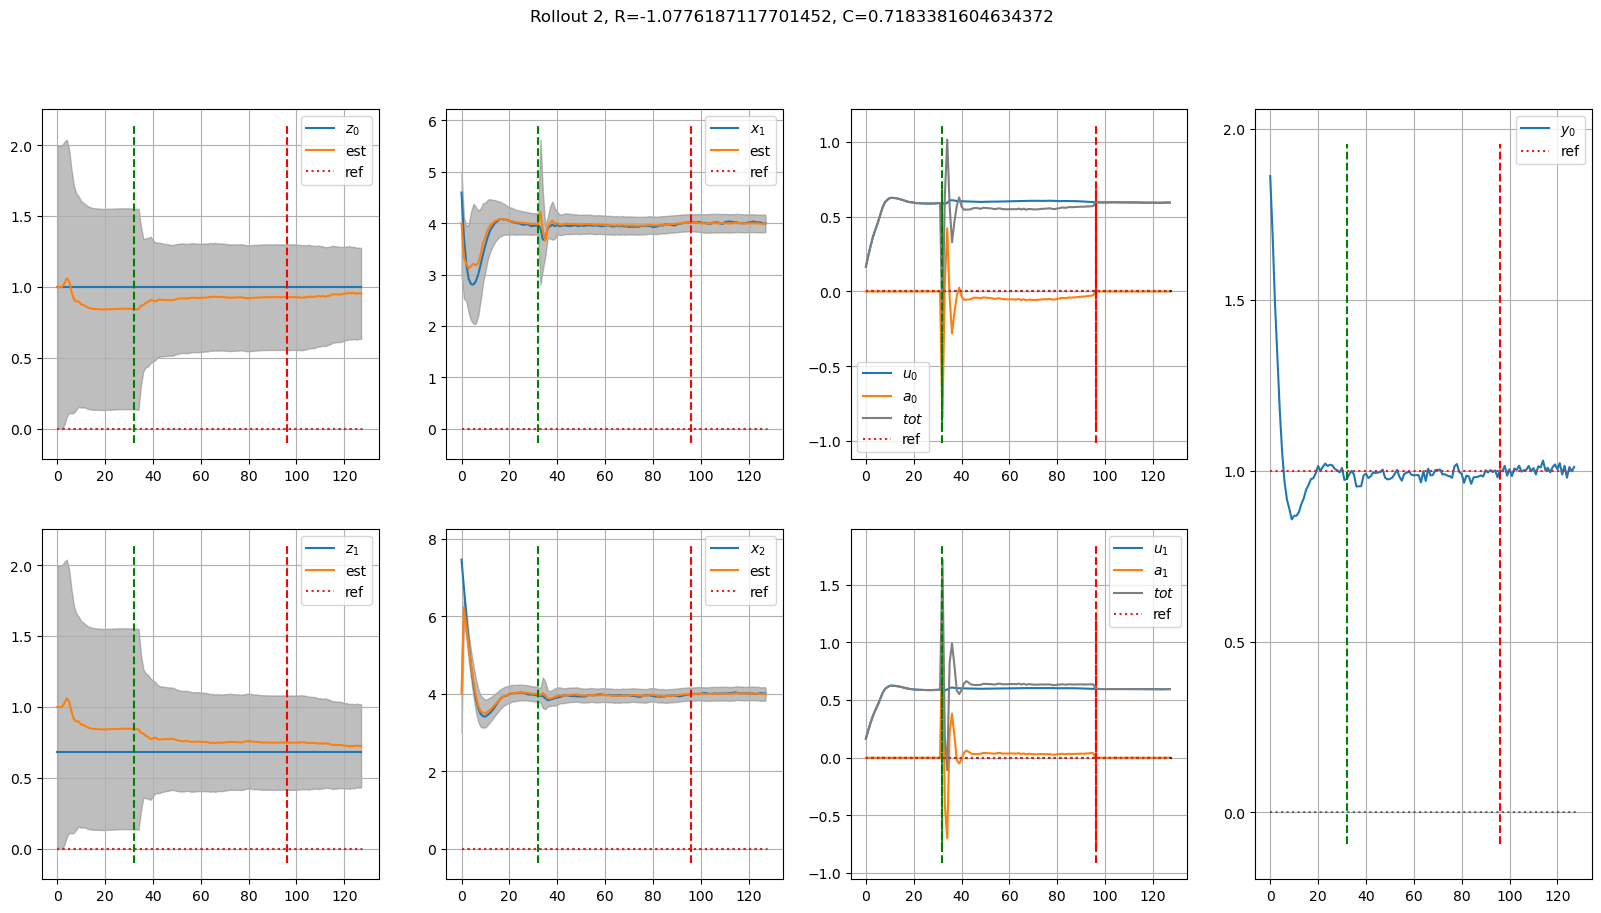

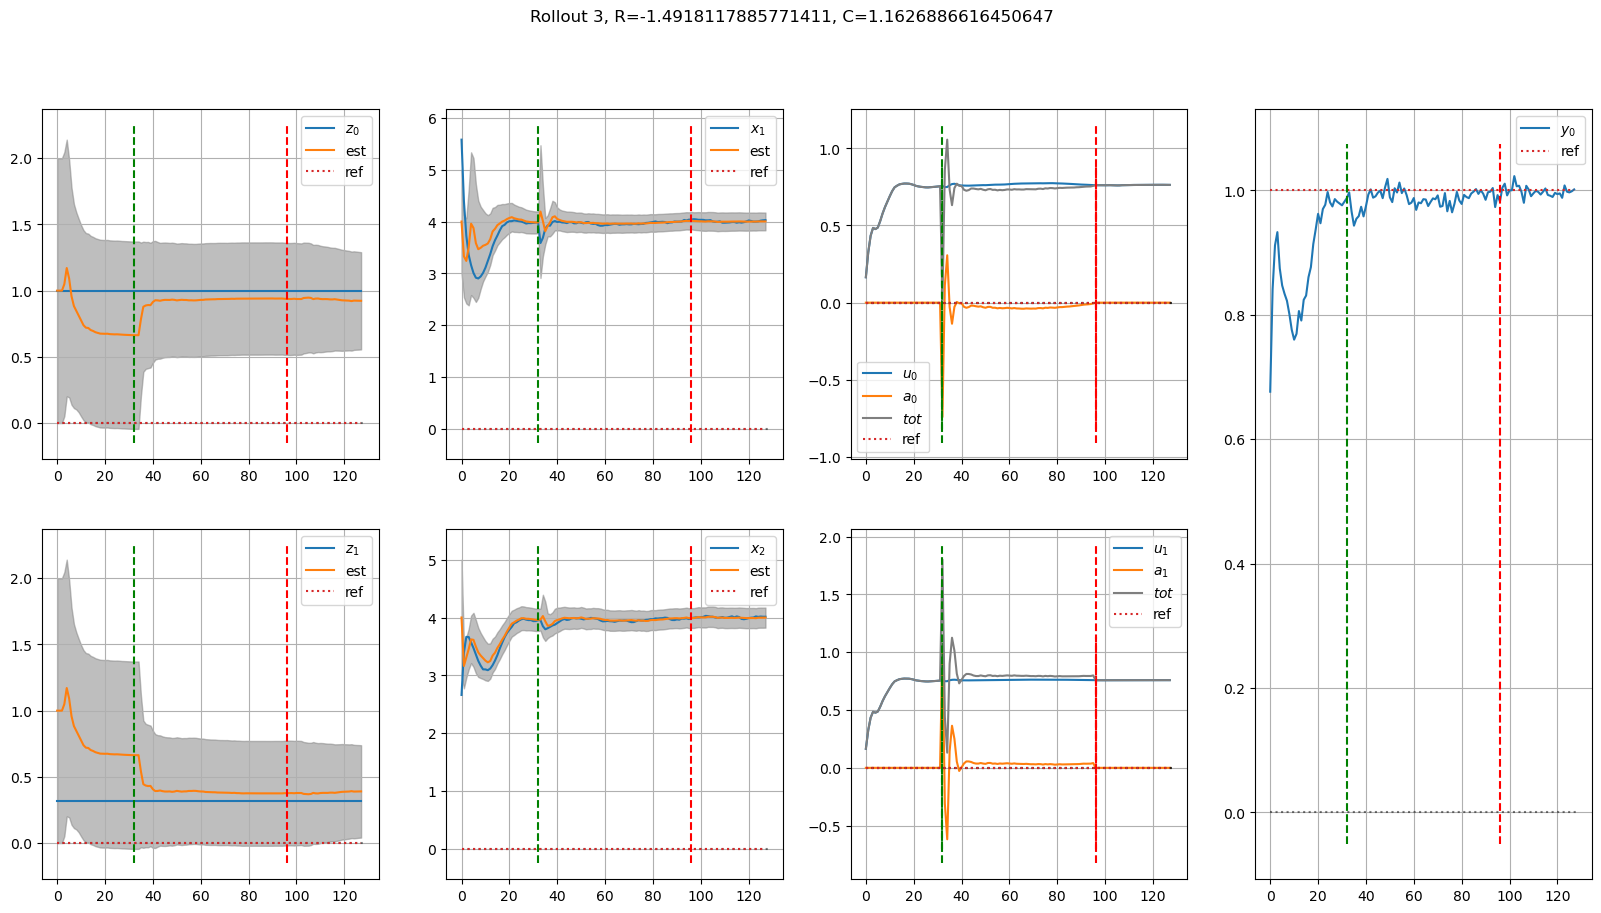

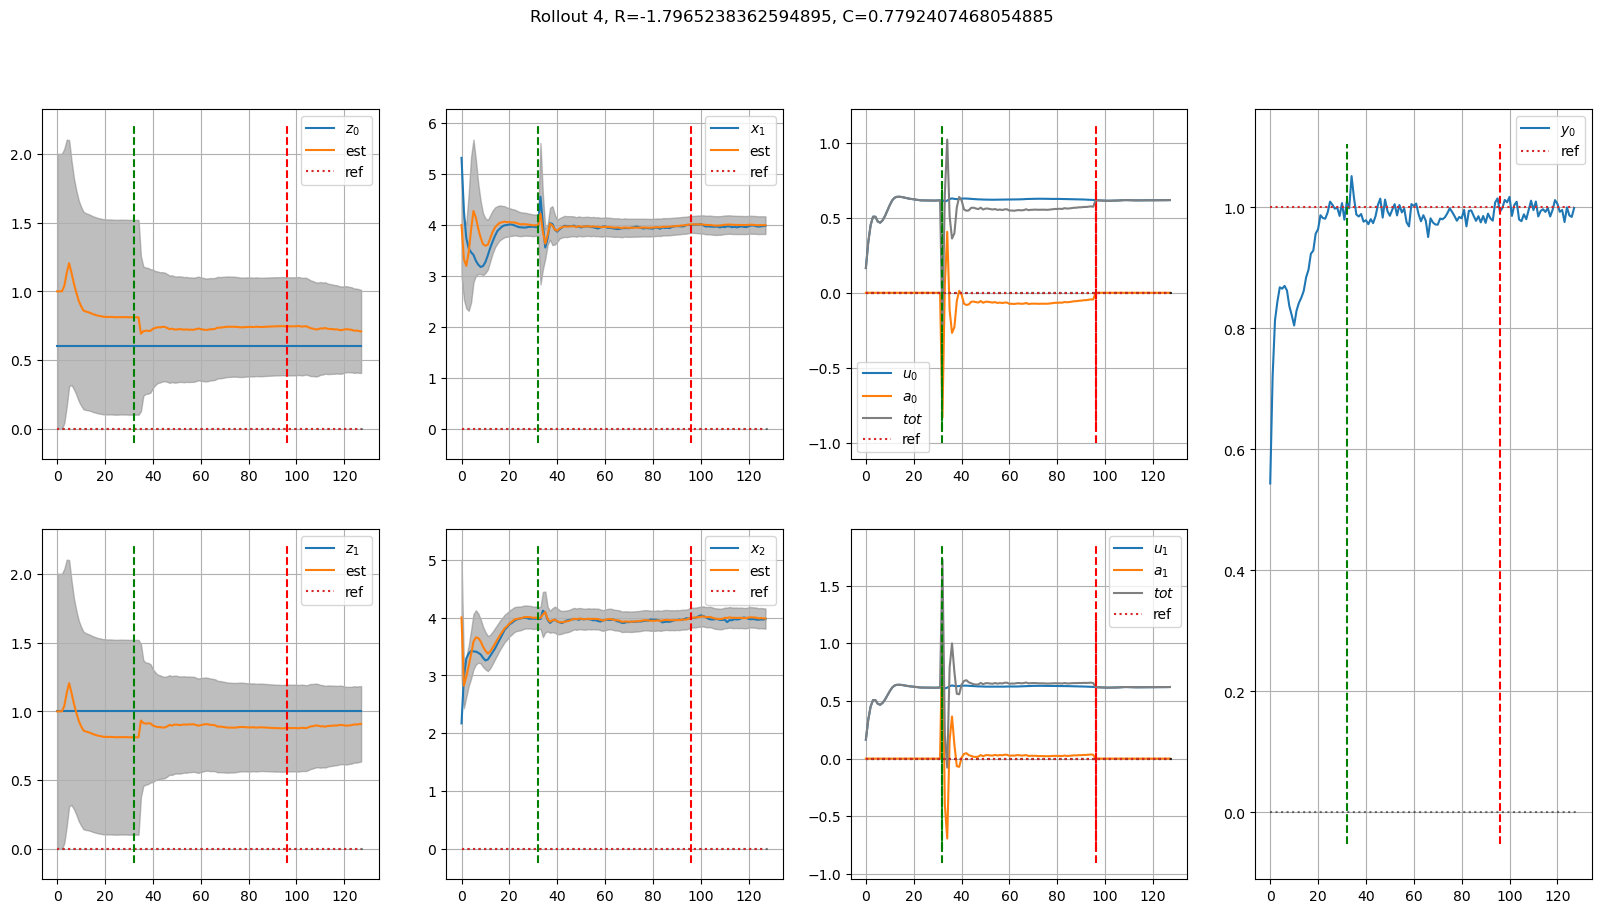

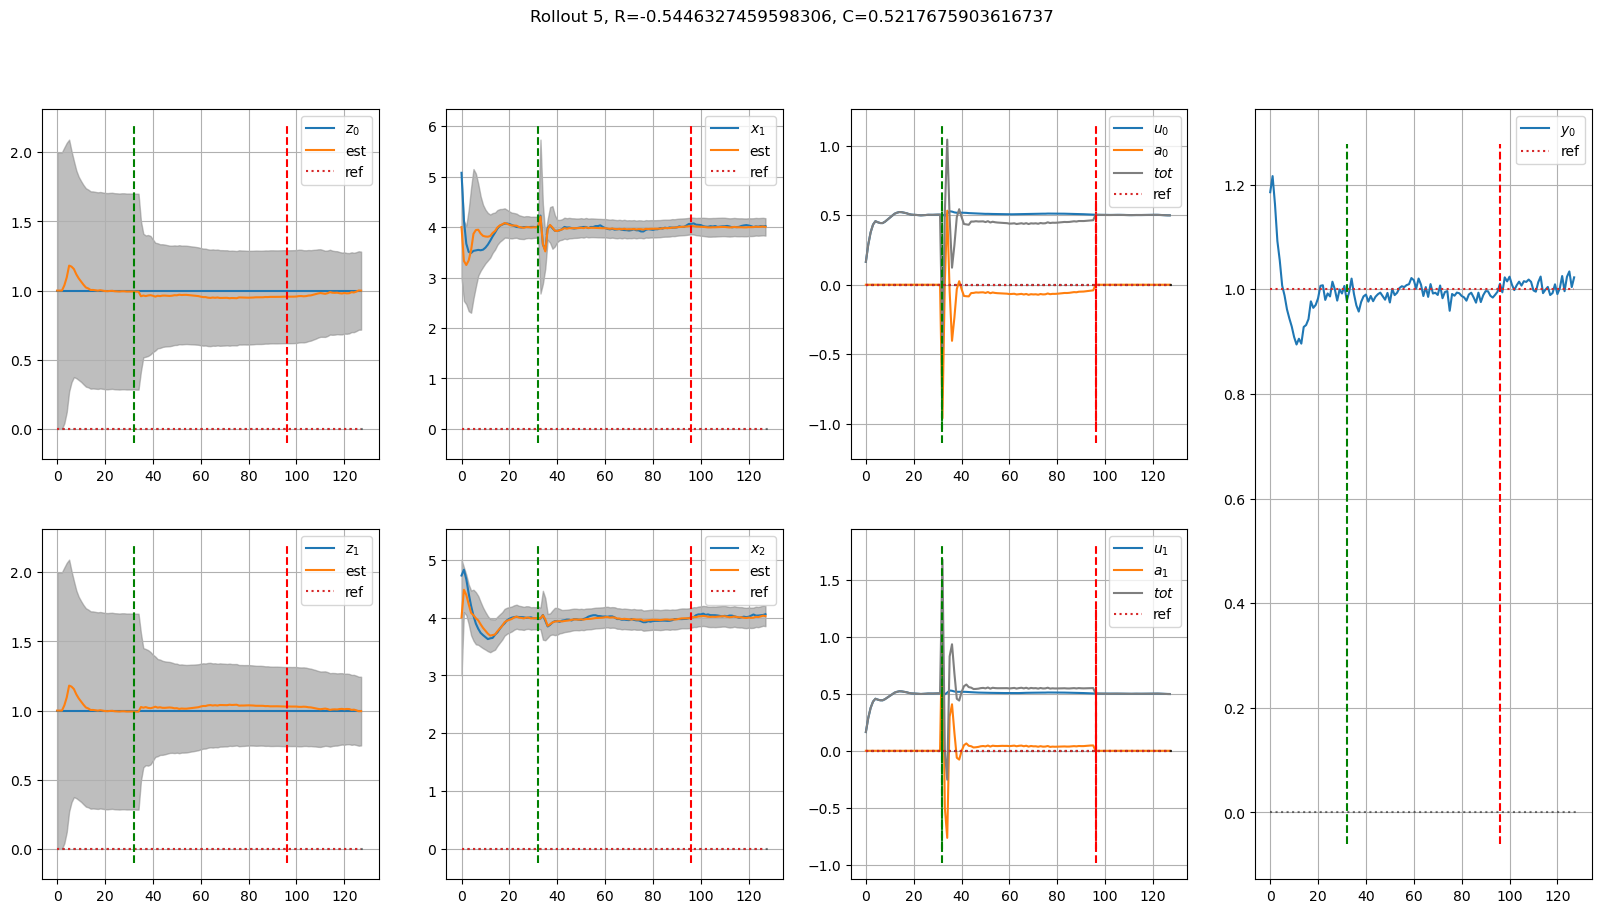

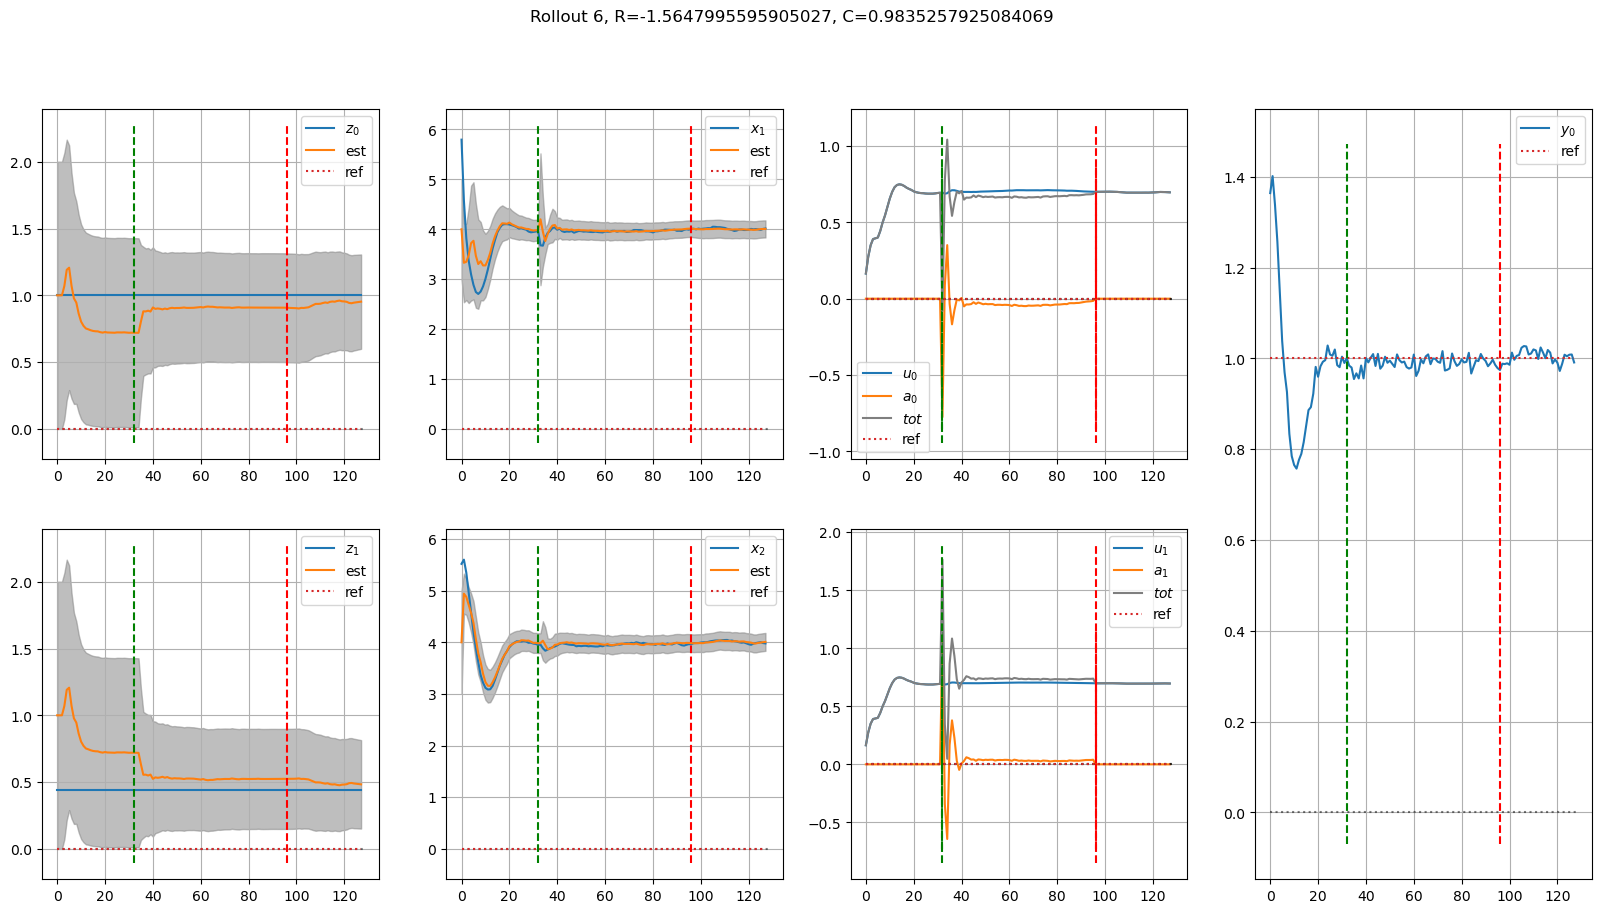

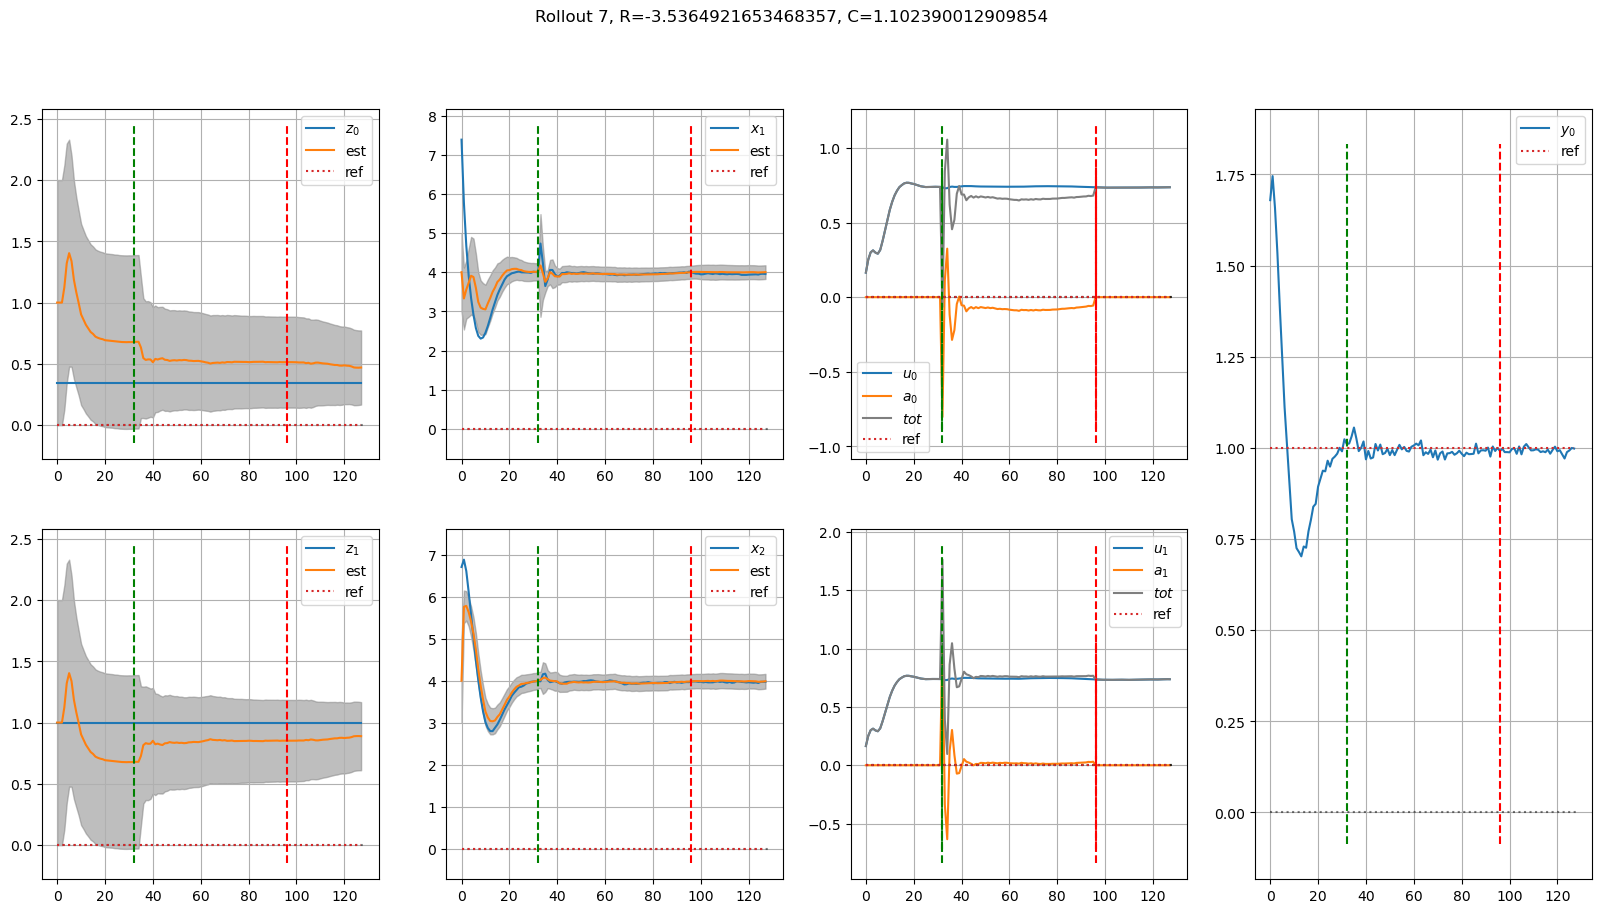

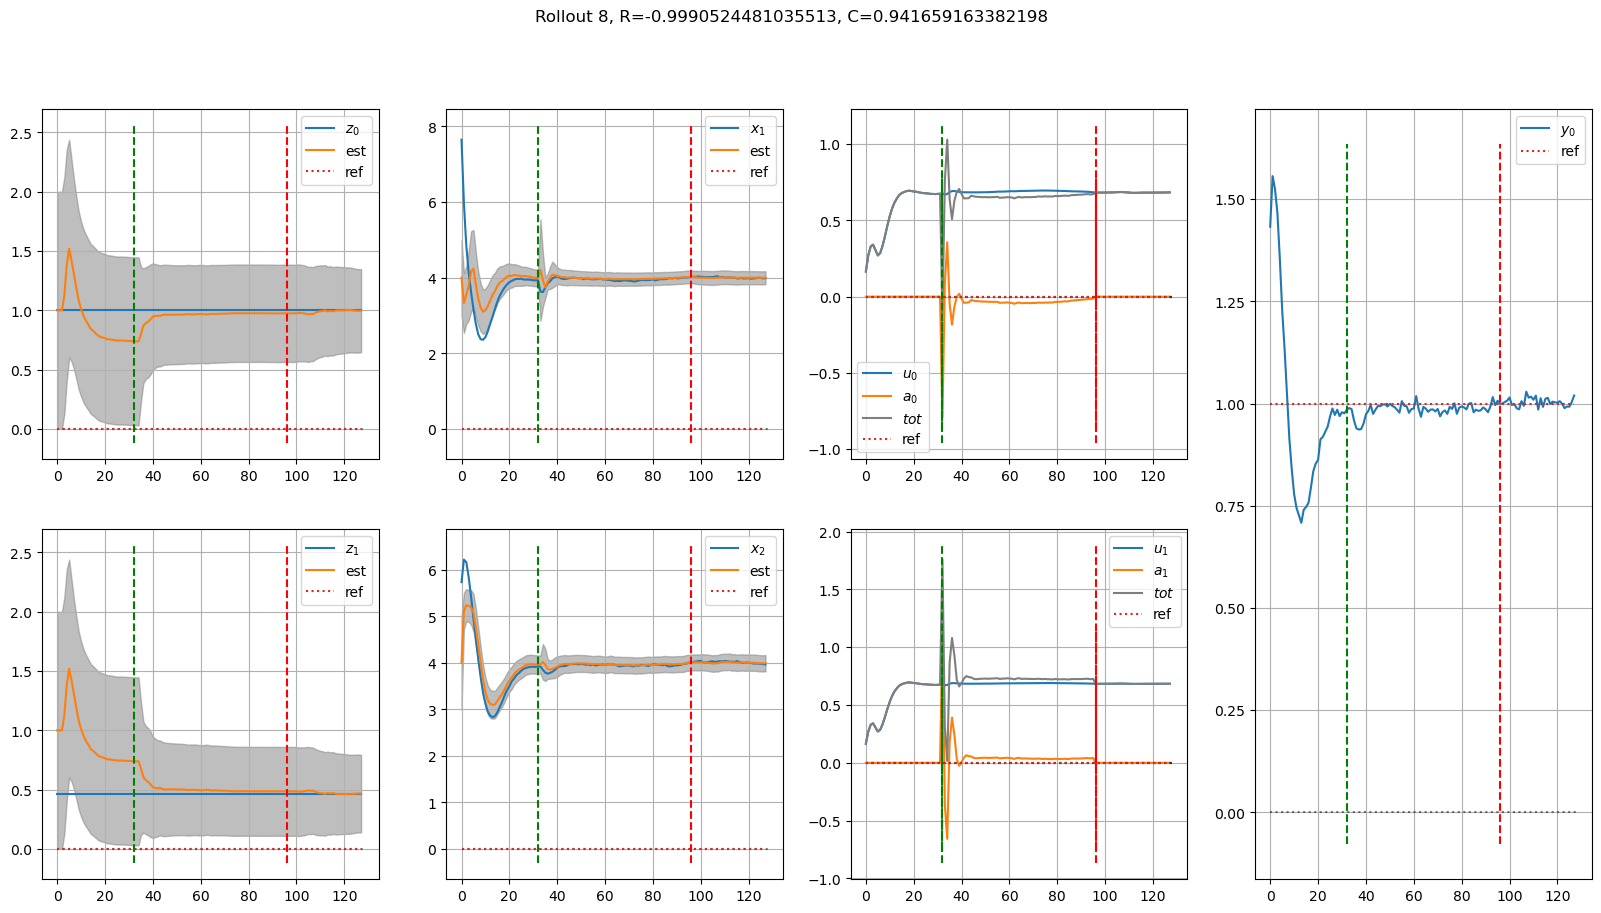

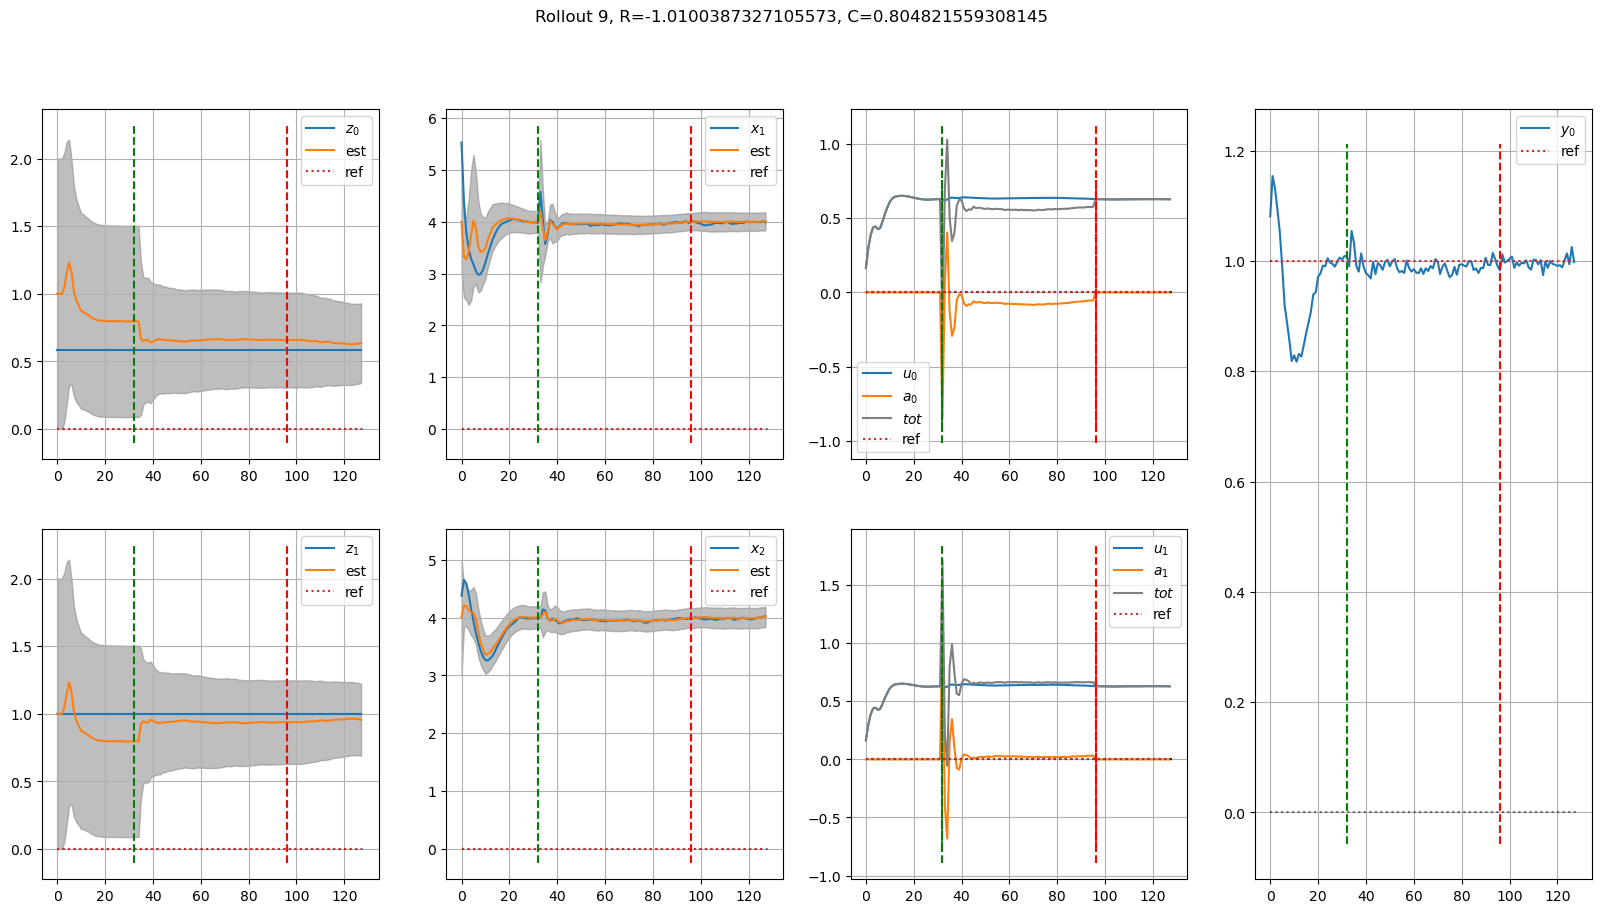

In [ ]:
trainer.policy.std.value *= 1e-20
for i in range(10):
    rollout, out = env.rollout(trainer.policy, 128)
    R, _ = get_returns(rollout.r, trainer.discount)
    C, _ = get_returns(rollout.c, trainer.discount)
    env.render(out, title=f"Rollout {i}, R={R}, C={C}")